# Income Trends and Inequality in Denmark, 2014–2023

**Guido Di Santo** · Probability and Statistics project

How did the income distribution of Danish families change between 2014 and 2023?
This notebook explores national trends, differences between family types, and
municipal variation using counts of families in ten income bands.

The analysis starts from five questions:

1. How did estimated mean income change for all families, couples, and single people?
2. How did annual growth vary, particularly during 2020–2022?
3. How did inequality, measured by a grouped-data Gini coefficient, evolve?
4. How closely did estimated mean income and inequality move together?
5. How did the share in the lowest income band change in Copenhagen, and how did municipalities compare in 2023?

Six extensions examine the full band distribution, family composition, inflation,
open-band sensitivity, annual changes in income and inequality, and municipal
trajectories. Each extension states its purpose, method, and interpretation.

**Reading the results.** Income levels and Gini coefficients are approximations
based on fixed representative incomes for each band. The analysis is descriptive:
it does not estimate causal effects, official poverty rates, or changes in wealth.
“All families” includes both couples and single people; these are an aggregate
and its two component groups, not three separate populations.

### Contents

- [1. Data and setup](#1-data-and-setup)
- [2. Estimating mean income](#2-estimating-mean-income)
- [3. Annual income growth](#3-annual-income-growth)
- [4. Income inequality](#4-income-inequality)
- [5. Income and inequality](#5-income-and-inequality)
- [6. Copenhagen](#6-copenhagen)
- [7. Municipal comparisons](#7-municipal-comparisons)
- [8. Conclusions and limitations](#8-conclusions-and-limitations)
- [9. Data provenance and references](#9-data-provenance-and-references)

### Extended analyses

| Analysis | Location |
| :--- | :--- |
| Full income-band distribution | [Section 2.3](#full-distribution) |
| Family composition and aggregate income | [Section 2.4](#family-composition) |
| Inflation adjustment | [Section 3.2](#inflation-adjustment) |
| Sensitivity to open-band assumptions | [Section 4.3](#open-band-sensitivity) |
| Correlation of annual changes | [Section 5.2](#annual-change-correlation) |
| Municipal evolution, 2014–2023 | [Section 7.5](#municipal-evolution) |


<a id="1-data-and-setup"></a>
## 1. Data and setup

Run the notebook from its project directory, using the Python environment described
in `README.md`. All paths are relative to that directory. Execute the cells in order
to reproduce the tables and figures.

The analysis uses four local data files and a source archive:

| File | Purpose |
| :--- | :--- |
| `family_income_dk2014-2023.csv` | Family counts by income band, family type, municipality, and year |
| `gadm41_DNK_1.json` | Regional boundaries used as a geographic backdrop |
| `dk.json` | Settlement names and coordinates used to position map markers |
| `denmark_cpi_2014-2023.csv` | Official annual consumer price index, Statistics Denmark PRIS8 |
| `data_sources/` | API requests, metadata, and an archived income-source comparison |

The supplied snapshots make execution independent of a live API connection.
The price data and the source-verification extract were retrieved on **4 October 2026**.


In [1]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd
from IPython.display import display

%matplotlib inline

DATA_DIR = Path.cwd()
YEARS = [str(year) for year in range(2014, 2024)]
GROUPS = {
    "Families, total": "All families",
    "Couples, total": "Couples",
    "Single people, total": "Single people",
}
COLORS = {"All families": "#2864A5", "Couples": "#C46B17", "Single people": "#22856A"}
LOWEST_BAND = "Less than 200,000 DKK"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})

### 1.1 Structure of the income data

The semicolon-separated CSV contains **3,267 rows**: 99 geographic entries
(Denmark as a whole and 98 municipalities), three family categories, and eleven
income categories (ten bands plus a total). The ten year columns cover 2014–2023.

| Original column | Name used below | Meaning |
| :--- | :--- | :--- |
| `c1` | `measure` | Measurement unit: number of families in the group |
| `c2` | `income_band` | Income interval, or `Total` |
| `c3` | `family_type` | All families, couples, or single people |
| `place` | `place` | National aggregate or municipality |
| `2014`–`2023` | Unchanged | Number of family units in each year |

The dataset contains **counts**, rather than individual income records. The unit
is a family unit within the stated category, so counts must not be interpreted
as the number of residents or tax returns. The file does not contain an explicit
income-definition field. A comparison with Statistics Denmark INDKF122 matches
all observed counts (Section 1.3), supporting its identification as a family
income-before-tax table. The original extraction date and processing notes
remain unavailable. The price adjustment makes its current-price interpretation explicit.

The marker `..` is read as missing, never as zero. Some municipal counts in higher
income bands are unavailable; the national bands and the municipal totals and
lowest-band counts used here are complete.

In [2]:
required_files = [
    "family_income_dk2014-2023.csv", "gadm41_DNK_1.json", "dk.json",
    "denmark_cpi_2014-2023.csv", "data_sources/INDKF122.verification.csv.gz",
]
missing_files = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(f"Run from the project directory. Missing files: {missing_files}")

income = pd.read_csv(
    DATA_DIR / "family_income_dk2014-2023.csv",
    sep=";",
    na_values=[".."],
).rename(columns={"c1": "measure", "c2": "income_band", "c3": "family_type"})

income[YEARS] = income[YEARS].apply(pd.to_numeric, errors="raise")
print(f"Loaded {len(income):,} rows covering {len(YEARS)} years.")
display(income.head())

Loaded 3,267 rows covering 10 years.


,measure,income_band,family_type,place,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Families in the group (Number),Total,"Families, total",All Denmark,2882246.0,2913147.0,2943524.0,2973031.0,2995484.0,3014327.0,3042302.0,3066273.0,3087026.0,3118634.0
1,Families in the group (Number),Total,"Families, total",Copenhagen,343970.0,349454.0,354843.0,360914.0,366895.0,371417.0,377095.0,381659.0,384503.0,388467.0
2,Families in the group (Number),Total,"Families, total",Frederiksberg,60036.0,60418.0,60653.0,60256.0,59846.0,59789.0,59842.0,60114.0,60472.0,60701.0
3,Families in the group (Number),Total,"Families, total",Dragør,6464.0,6501.0,6583.0,6628.0,6638.0,6746.0,6776.0,6791.0,6722.0,6742.0
4,Families in the group (Number),Total,"Families, total",Tårnby,20869.0,21050.0,21193.0,21261.0,21241.0,21235.0,21137.0,21191.0,21230.0,21660.0


### 1.2 Data checks

Before estimating income, check that records are unique, observed counts are
nonnegative integers, national band counts reconcile with their totals, and
the aggregate family category equals couples plus single people wherever all
three counts are observed. Municipal comparisons require complete totals and
lowest-band counts. Missing higher-band counts are retained as missing and are
not reconstructed.

In [3]:
keys = ["place", "family_type", "income_band"]
assert not income.duplicated(keys).any(), "Duplicate geographic/group/band records."
assert set(income["measure"]) == {"Families in the group (Number)"}
assert set(income["family_type"]) == set(GROUPS)
assert income["place"].nunique() == 99
assert len(income) == 99 * 3 * 11
observed = income[YEARS].to_numpy(dtype=float)
observed = observed[np.isfinite(observed)]
assert (observed >= 0).all() and (observed == np.floor(observed)).all()

national = income.loc[income["place"].eq("All Denmark")].copy()
assert national[YEARS].notna().all().all(), "National counts must be complete."
for family_type in GROUPS:
    block = national.loc[national["family_type"].eq(family_type)].set_index("income_band")
    np.testing.assert_allclose(block.drop(index="Total")[YEARS].sum(), block.loc["Total", YEARS])

counts_by_group = income.set_index(keys)[YEARS]
family_counts = counts_by_group.xs("Families, total", level="family_type").sort_index()
component_counts = (
    counts_by_group.xs("Couples, total", level="family_type").sort_index()
    + counts_by_group.xs("Single people, total", level="family_type").sort_index()
)
comparable = family_counts.notna() & component_counts.notna()
assert family_counts.eq(component_counts).where(comparable, True).all().all()

municipal = income.loc[income["place"].ne("All Denmark")].copy()
required_counts = municipal.loc[municipal["income_band"].isin(["Total", LOWEST_BAND])]
assert required_counts[YEARS].notna().all().all()
assert (required_counts.loc[required_counts["income_band"].eq("Total"), YEARS] > 0).all().all()
print(f"Data checks passed. Missing count values retained: {income[YEARS].isna().sum().sum()}.")

Data checks passed. Missing count values retained: 67.


### 1.3 Checking the income source

To support the interpretation required for the inflation adjustment, compare
the local counts with an archived extract of [Statistics Denmark INDKF122](https://www.statistikbanken.dk/statbank5a/SelectVarVal/Define.asp?MainTable=INDKF122).
The official table identifies family income before tax. All **32,603 observed
values** in the local file match the extract at the same municipality, family
type, income band, unit, and year. This provides strong evidence for the table
identification, although it does not recover the original download history.

The check below is reproducible offline. It does not fill the **67 missing
local values**. Source requests, metadata, retrieval date, and checksums are
recorded in `data_sources/`.

In [4]:
official_counts = pd.read_csv(
    DATA_DIR / "data_sources/INDKF122.verification.csv.gz", sep=";", na_values=[".."]
).rename(columns={
    "OMRÅDE": "place", "ENHED": "measure", "FAMTYP": "family_type",
    "INDKINTB": "income_band", "TID": "year", "INDHOLD": "official_count",
})
local_long = income.melt(
    id_vars=["measure", "income_band", "family_type", "place"],
    value_vars=YEARS, var_name="year", value_name="local_count",
)
local_long["year"] = local_long["year"].astype(int)
source_keys = ["measure", "income_band", "family_type", "place", "year"]
source_check = local_long.merge(official_counts, on=source_keys, how="outer",
                               validate="one_to_one", indicator=True)
assert source_check["_merge"].eq("both").all()
observed_source = source_check.loc[source_check["local_count"].notna()]
assert observed_source["official_count"].notna().all()
np.testing.assert_array_equal(observed_source["local_count"], observed_source["official_count"])
print(f"Source comparison: {len(observed_source):,} observed counts match INDKF122 exactly.")

Source comparison: 32,603 observed counts match INDKF122 exactly.


<a id="2-estimating-mean-income"></a>
## 2. Estimating mean income

### 2.1 A weighted estimate from income bands

For each group and year, assign a representative income $m_i$ to band $i$ and
weight it by the number of family units $n_{i,t}$ in that band:

$$
\widehat{\mu}_t = \frac{\sum_{i=1}^{K} n_{i,t}m_i}{\sum_{i=1}^{K} n_{i,t}},
\qquad K=10.
$$

The representative incomes below preserve the assumptions of the original
project. Closed bands use rounded midpoints. The lowest band is assigned
**DKK 100,000** and the open upper band **DKK 1,200,000**. These two values are
assumptions, not observed band means; the lower band can also contain incomes
that the positive representative value does not capture.

The same values are used in every year. The estimates therefore describe shifts
between bands and cannot detect changes within a band. The baseline estimates
use the file's fixed DKK scale; Section 3.2 applies an annual consumer-price
deflator separately. No adjustment for family size is made. Neither version
is a direct measure of equivalent living standards.

In [5]:
# Match representative incomes by band label, rather than relying on CSV row order.
BAND_INCOMES = pd.Series({
    "Less than 200,000 DKK": 100_000,
    "200,000 - 299,999 DKK": 250_000,
    "300,000 - 399,999 DKK": 350_000,
    "400,000 - 499,999 DKK": 450_000,
    "500,000 - 599,999 DKK": 550_000,
    "600,000 - 699,999 DKK": 650_000,
    "700,000 - 799,000 DKK": 750_000,
    "800,000 - 899,000 DKK": 850_000,
    "900,000 - 999,000 DKK": 950_000,
    "1 million DKK, and more": 1_200_000,
}, name="Representative income (DKK)")
BAND_INCOMES.index.name = "Income band (CSV label)"
assert set(income["income_band"]) == set(BAND_INCOMES.index) | {"Total"}
display(BAND_INCOMES.to_frame())

,Representative income (DKK)
Income band (CSV label),
"Less than 200,000 DKK",100000
"200,000 - 299,999 DKK",250000
"300,000 - 399,999 DKK",350000
"400,000 - 499,999 DKK",450000
"500,000 - 599,999 DKK",550000
"600,000 - 699,999 DKK",650000
"700,000 - 799,000 DKK",750000
"800,000 - 899,000 DKK",850000
"900,000 - 999,000 DKK",950000


The CSV spells the upper limits of three bands as `799,000`, `899,000`, and
`999,000`. These labels are preserved for exact matching. The rounded values
750,000, 850,000, and 950,000 remain explicit modeling assumptions; the labels
have not been silently corrected in the source file.

In [6]:
def get_band_counts(family_type, place="All Denmark"):
    """Return complete band counts in ascending representative-income order."""
    selected = income.loc[
        income["family_type"].eq(family_type)
        & income["place"].eq(place)
        & income["income_band"].ne("Total")
    ].set_index("income_band")
    counts = selected.reindex(BAND_INCOMES.index)[YEARS]
    if counts.isna().any().any():
        raise ValueError(f"Missing band counts for {family_type} in {place}.")
    return counts


national_counts = {label: get_band_counts(key) for key, label in GROUPS.items()}
mean_income = pd.DataFrame({
    label: counts.mul(BAND_INCOMES, axis=0).sum() / counts.sum()
    for label, counts in national_counts.items()
}).rename_axis("Year")
display(mean_income.round(0).astype(int).rename_axis(columns="Estimated mean income (DKK)"))

Estimated mean income (DKK),All families,Couples,Single people
Year,,,
2014,454762,669283,268733
2015,461664,679467,274033
2016,468098,688595,278852
2017,476775,702570,284503
2018,485654,715308,291564
2019,496485,731142,299310
2020,514765,759131,311636
2021,531477,783164,324599
2022,535058,788259,329308


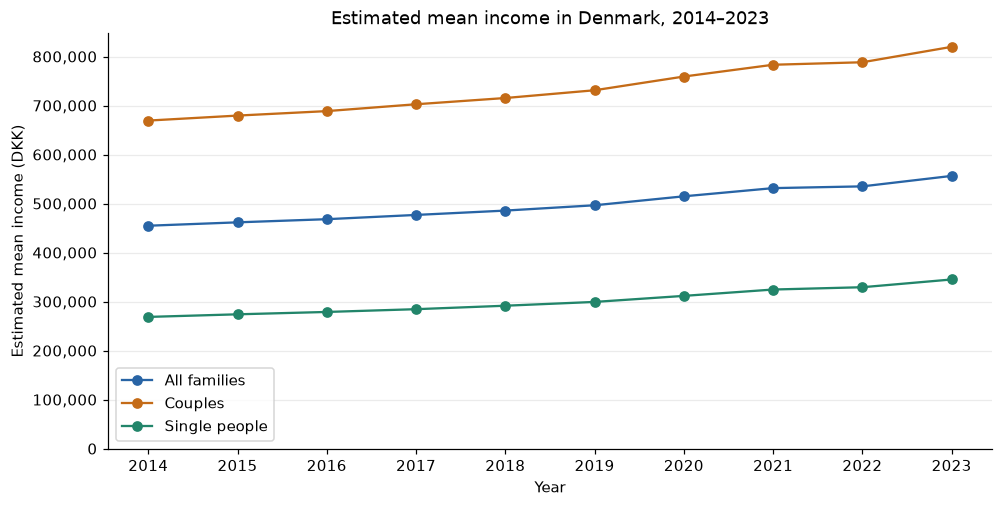

,2014 (DKK),2023 (DKK),Change (%)
Group,,,
All families,454762.40,556395.00,22.35
Couples,669283.12,819717.53,22.48
Single people,268733.32,345111.46,28.42


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for label in GROUPS.values():
    ax.plot(YEARS, mean_income[label], marker="o", label=label, color=COLORS[label])
ax.set(title="Estimated mean income in Denmark, 2014–2023",
       xlabel="Year", ylabel="Estimated mean income (DKK)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.show()

mean_summary = pd.DataFrame({
    "2014 (DKK)": mean_income.loc["2014"],
    "2023 (DKK)": mean_income.loc["2023"],
    "Change (%)": (mean_income.loc["2023"] / mean_income.loc["2014"] - 1) * 100,
}).rename_axis("Group")
display(mean_summary.round(2))

### 2.2 Interpretation

Estimated mean income rises over the period for all three series. For all
families, it increases from approximately **DKK 454,762** in 2014 to
**DKK 556,395** in 2023. Couples have higher estimated family income than single
people, but this comparison is not adjusted for the number of people supported
by that income.

The aggregate lies between the two component series. Its evolution reflects
both changes within each group and changes in their relative sizes. These are
income estimates, not estimates of wages alone.

<a id="full-distribution"></a>
### 2.3 Looking beyond the mean: the full income-band distribution

**Purpose.** An increasing mean can conceal different movements across the
distribution. Inspecting all ten bands shows where family units become more
or less concentrated without assigning an income to each unit.

For each group and year, the percentage in band $i$ is

$$p_{i,t}=100\frac{n_{i,t}}{\sum_j n_{j,t}}.$$

The heatmaps use a common color scale across groups. Each column sums to 100%.
The endpoint table reports **percentage-point changes**, not percentage changes
in the number of families. These repeated cross-sections describe changing
shares; they do not track individual families moving between bands.

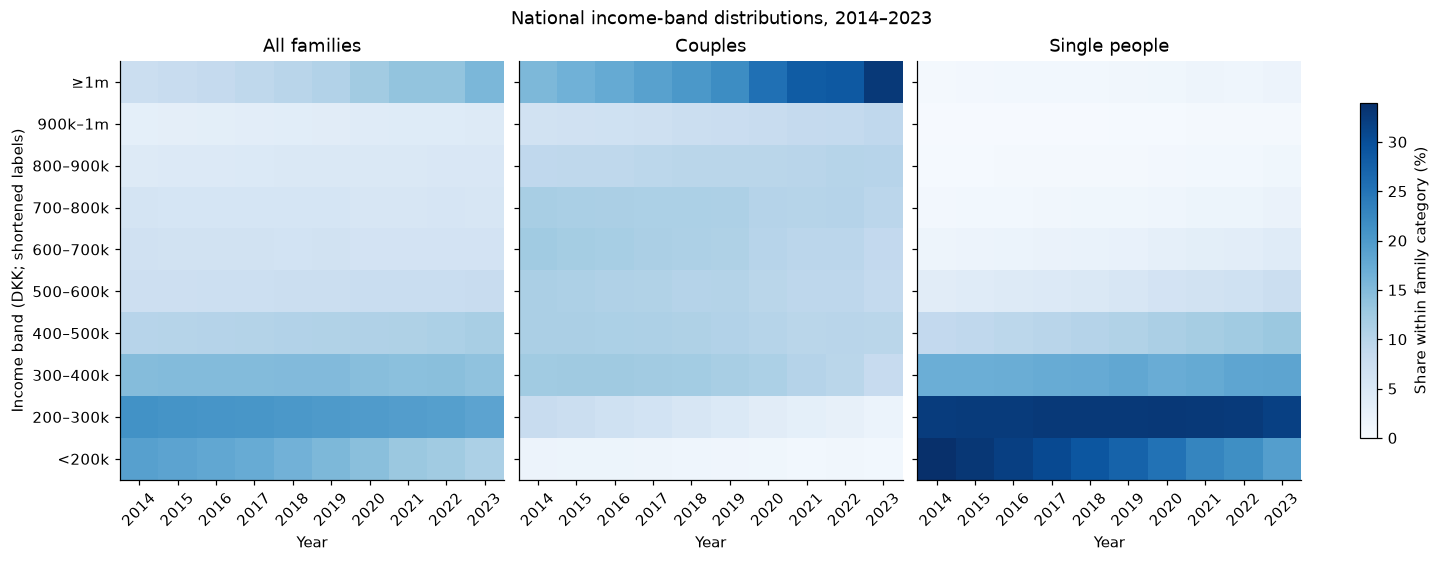

"Change, 2014–2023 (percentage points)",All families,Couples,Single people
Income band,,,
"Less than 200,000 DKK",-7.90,-0.92,-14.60
"200,000 - 299,999 DKK",-2.54,-6.09,-0.53
"300,000 - 399,999 DKK",-0.91,-4.11,1.49
"400,000 - 499,999 DKK",1.52,-1.57,4.09
"500,000 - 599,999 DKK",0.73,-2.60,3.67
"600,000 - 699,999 DKK",-0.55,-3.59,2.27
"700,000 - 799,000 DKK",-0.38,-2.01,1.30
"800,000 - 899,000 DKK",0.68,0.98,0.74
"900,000 - 999,000 DKK",1.31,2.62,0.47


In [8]:
band_shares = {
    label: counts.div(counts.sum(axis=0), axis=1) * 100
    for label, counts in national_counts.items()
}
for shares in band_shares.values():
    np.testing.assert_allclose(shares.sum(axis=0), 100)

band_labels = ["<200k", "200–300k", "300–400k", "400–500k", "500–600k",
               "600–700k", "700–800k", "800–900k", "900k–1m", "≥1m"]
max_share = max(shares.to_numpy().max() for shares in band_shares.values())
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True, layout="constrained")
for ax, (label, shares) in zip(axes, band_shares.items()):
    heatmap = ax.imshow(shares, origin="lower", aspect="auto", cmap="Blues", vmin=0, vmax=max_share)
    ax.set_xticks(range(len(YEARS)), YEARS, rotation=45)
    ax.set_yticks(range(len(band_labels)), band_labels)
    ax.set(title=label, xlabel="Year")
axes[0].set_ylabel("Income band (DKK; shortened labels)")
fig.colorbar(heatmap, ax=list(axes), label="Share within family category (%)", shrink=0.8)
fig.suptitle("National income-band distributions, 2014–2023")
plt.show()

band_share_changes = pd.DataFrame({
    label: shares["2023"] - shares["2014"] for label, shares in band_shares.items()
}).rename_axis("Income band")
display(band_share_changes.round(2).rename_axis(columns="Change, 2014–2023 (percentage points)"))

For all families, the lowest-band share falls from **19.08% to 11.18%**, while
the highest-band share rises from **7.58% to 15.61%**. Among couples, the share
above DKK 1 million rises from **15.39% to 32.69%**. These shifts explain why the
assumed income in the highest band matters increasingly to estimated means and
inequality. Inflation can itself move families across these fixed DKK thresholds;
Section 3.2 addresses prices for the estimated means.

<a id="family-composition"></a>
### 2.4 Separating changes within groups from changes in family composition

**Purpose.** The aggregate mean can change because the mean within each group
changes, because the relative numbers of couples and single people change, or
both. An accounting decomposition separates these contributions.

Let $w_{g,t}$ be group $g$'s share of all family units and $\mu_{g,t}$ its
estimated mean. Use only the two component groups, so that
$\mu_t=\sum_g w_{g,t}\mu_{g,t}$ and $\sum_g w_{g,t}=1$.
Between 2014 (0) and 2023 (1), the symmetric decomposition is exact:

$$
\mu_1-\mu_0=
\underbrace{\sum_g\frac{w_{g,1}+w_{g,0}}{2}(\mu_{g,1}-\mu_{g,0})}_{\text{within-group contribution}}
+\underbrace{\sum_g\frac{\mu_{g,1}+\mu_{g,0}}{2}(w_{g,1}-w_{g,0})}_{\text{composition contribution}}.
$$

Averaging the two endpoints avoids choosing either year's weights as the sole
reference and splits the interaction symmetrically. The contributions are in
**DKK per family unit**, not total national income. This is an accounting identity,
not a causal estimate, and the within-group term can itself include demographic
changes inside each group.

As a complementary illustration, hold the **2014 group shares** constant for
every year. This standardized series answers what the aggregate mean would be
under that particular composition; it is distinct from the symmetric decomposition.

,Within-group contribution (DKK),Composition contribution (DKK),Total contribution (DKK)
Group,,,
Couples,68418.40,-14337.36,54081.04
Single people,41640.94,5910.62,47551.56
Total,110059.34,-8426.74,101632.60


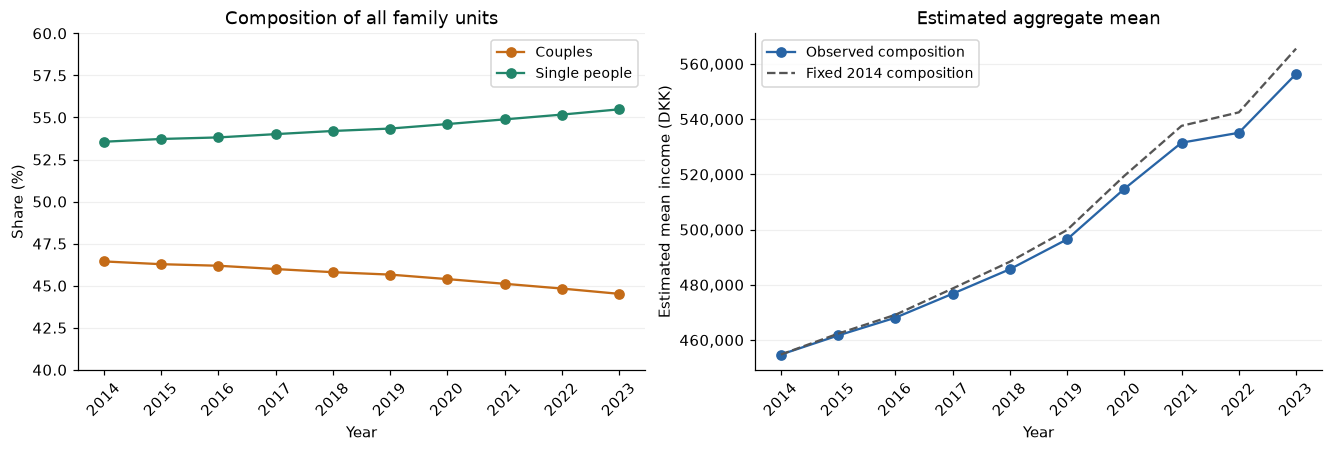

In [9]:
component_labels = ["Couples", "Single people"]
component_totals = pd.DataFrame({
    label: national_counts[label].sum(axis=0) for label in component_labels
})
group_weights = component_totals.div(component_totals.sum(axis=1), axis=0)
np.testing.assert_allclose(group_weights.sum(axis=1), 1)
component_means = mean_income[component_labels]
reconstructed_mean = (group_weights * component_means).sum(axis=1)
np.testing.assert_allclose(reconstructed_mean, mean_income["All families"])

w0, w1 = group_weights.loc["2014"], group_weights.loc["2023"]
mu0, mu1 = component_means.loc["2014"], component_means.loc["2023"]
composition_decomposition = pd.DataFrame({
    "Within-group contribution (DKK)": (w0 + w1) / 2 * (mu1 - mu0),
    "Composition contribution (DKK)": (mu0 + mu1) / 2 * (w1 - w0),
}).rename_axis("Group")
composition_decomposition["Total contribution (DKK)"] = composition_decomposition.sum(axis=1)
composition_decomposition.loc["Total"] = composition_decomposition.sum(axis=0)
aggregate_change = mean_income.loc["2023", "All families"] - mean_income.loc["2014", "All families"]
np.testing.assert_allclose(composition_decomposition.loc["Total", "Total contribution (DKK)"], aggregate_change)
fixed_2014_mean = component_means.mul(w0, axis=1).sum(axis=1)
display(composition_decomposition.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for label in component_labels:
    axes[0].plot(YEARS, group_weights[label] * 100, marker="o", color=COLORS[label], label=label)
axes[0].set(title="Composition of all family units", xlabel="Year", ylabel="Share (%)")
axes[0].set_ylim(40, 60)
axes[1].plot(YEARS, mean_income["All families"], marker="o", label="Observed composition", color=COLORS["All families"])
axes[1].plot(YEARS, fixed_2014_mean, linestyle="--", label="Fixed 2014 composition", color="#555555")
axes[1].set(title="Estimated aggregate mean", xlabel="Year", ylabel="Estimated mean income (DKK)")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=9)
plt.show()

The aggregate increase of **DKK 101,633** consists of approximately
**+DKK 110,059 within groups** and **−DKK 8,427 from changing group weights**
(rounded separately). The couples' share falls from **46.44% to 44.52%**.
Because couples have the higher estimated family income, that compositional
shift offsets part of the increase within the two groups. It does not imply
that changes in family structure caused any individual family's income to fall.

<a id="3-annual-income-growth"></a>
## 3. Annual income growth

### 3.1 Changes on the original DKK scale

To compare the pace of change, calculate the year-on-year percentage change:

$$
g_t = 100\left(\frac{\widehat{\mu}_t}{\widehat{\mu}_{t-1}} - 1\right).
$$

The first observation has no growth rate because the file does not include 2013.
The years 2020–2022 provide a useful descriptive comparison around the pandemic,
but this dataset alone cannot identify the causes of a slowdown or acceleration.

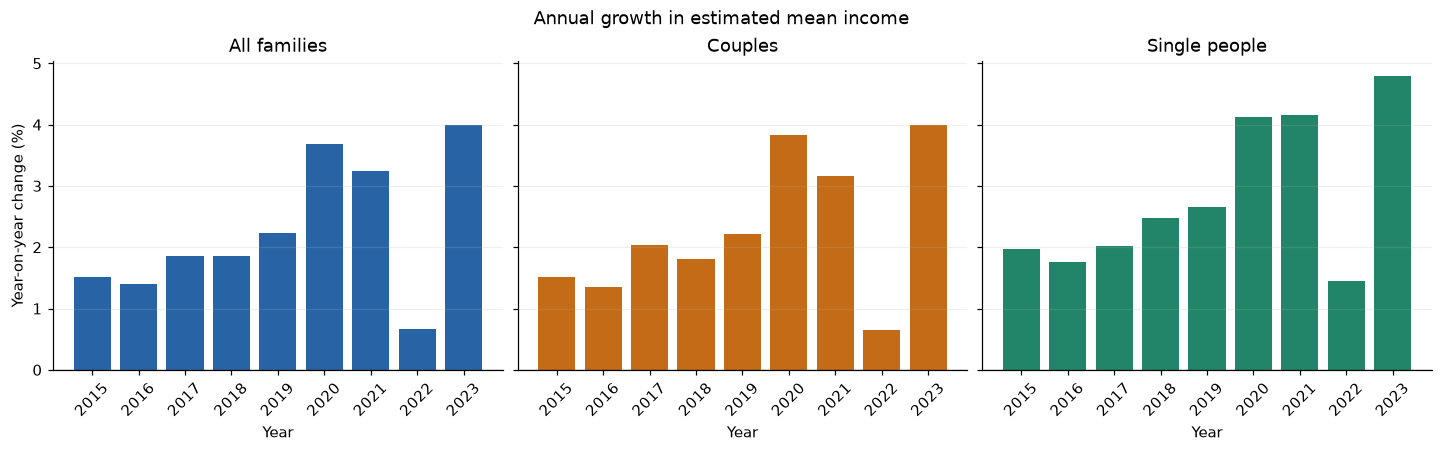

Growth (%),All families,Couples,Single people
Year,,,
2020,3.68,3.83,4.12
2021,3.25,3.17,4.16
2022,0.67,0.65,1.45
2023,3.99,3.99,4.80


In [10]:
annual_growth = mean_income.pct_change(fill_method=None) * 100
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    ax.bar(YEARS[1:], annual_growth.loc[YEARS[1:], label], color=COLORS[label])
    ax.set(title=label, xlabel="Year")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Year-on-year change (%)")
fig.suptitle("Annual growth in estimated mean income")
plt.show()
display(annual_growth.loc["2020":"2023"].round(2).rename_axis(columns="Growth (%)"))

The slowdown is most pronounced in **2022**, when growth falls to **0.67%** for
all families, **0.65%** for couples, and **1.45%** for single people. In both
2020 and 2021, the corresponding growth rates exceed 3%; growth increases again
in 2023.

These figures establish the timing of the change. Attributing it to the
pandemic, inflation, policy measures, or labor-market conditions would require
additional evidence and an appropriate causal analysis.

<a id="inflation-adjustment"></a>
### 3.2 Adjusting estimated income for consumer-price inflation

**Purpose.** More DKK need not buy proportionately more goods and services.
Use the annual-average consumer price index from
[Statistics Denmark PRIS8](https://www.statbank.dk/PRIS8) to express the estimates
in **2014 DKK**. Annual averages match the annual frequency of the income data.
The raw PRIS8 series is indexed to 1900; only ratios matter for the adjustment.

If $P_t$ denotes the annual CPI, define

$$\widehat{\mu}^{\mathrm{real}}_t=\widehat{\mu}^{\mathrm{nominal}}_t\frac{P_{2014}}{P_t},
\qquad
g^{\mathrm{real}}_t=100\left(\frac{\widehat{\mu}^{\mathrm{real}}_t}
{\widehat{\mu}^{\mathrm{real}}_{t-1}}-1\right).$$

**Price-basis assumption.** The complete observed-count match to INDKF122
supports the income-before-tax interpretation. We treat the file's DKK bands
as current-year amounts; because the original extraction notes are unavailable,
the deflation remains conditional on that interpretation. It would be inappropriate
to deflate a series already expressed in constant prices.

The CPI is a national average, not a separate cost-of-living index for each
family category. It does not account for taxes or family size, and it does not
remove errors from the representative-income model. PRIS8 also flags greater
uncertainty in parts of 2020 during business closures and elevated nonresponse.
See the [official CPI documentation](https://www.dst.dk/en/Statistik/dokumentation/documentationofstatistics/consumer-price-index/statistical-presentation).

In [11]:
cpi_raw = pd.read_csv(DATA_DIR / "denmark_cpi_2014-2023.csv", sep=";")
assert set(cpi_raw["TYPE"]) == {"Consumer price index"}
assert cpi_raw["TID"].is_unique
assert set(cpi_raw["TID"].astype(str)) == set(YEARS)
cpi = cpi_raw.assign(Year=cpi_raw["TID"].astype(str)).set_index("Year")["INDHOLD"].reindex(YEARS)
cpi = pd.to_numeric(cpi, errors="raise").rename("Annual CPI (1900=100)")
assert cpi.notna().all() and (cpi > 0).all()
cpi_2014 = 100 * cpi / cpi.loc["2014"]
inflation_pct = cpi.pct_change(fill_method=None) * 100
display(pd.DataFrame({"CPI (1900=100)": cpi, "CPI (2014=100)": cpi_2014,
                      "Annual inflation (%)": inflation_pct}).round(2))

,CPI (1900=100),CPI (2014=100),Annual inflation (%)
Year,,,
2014,6860,100.00,NaN
2015,6891,100.45,0.45
2016,6909,100.71,0.26
2017,6988,101.87,1.14
2018,7045,102.70,0.82
2019,7098,103.47,0.75
2020,7128,103.91,0.42
2021,7260,105.83,1.85
2022,7819,113.98,7.70


,2014 income (2014 DKK),2023 income (2014 DKK),"Nominal change, 2014–2023 (%)","Real change, 2014–2023 (%)",Real growth in 2022 (%)
Group,,,,,
All families,454762.40,472560.32,22.35,3.91,-6.52
Couples,669283.12,696206.79,22.48,4.02,-6.55
Single people,268733.32,293111.87,28.42,9.07,-5.80


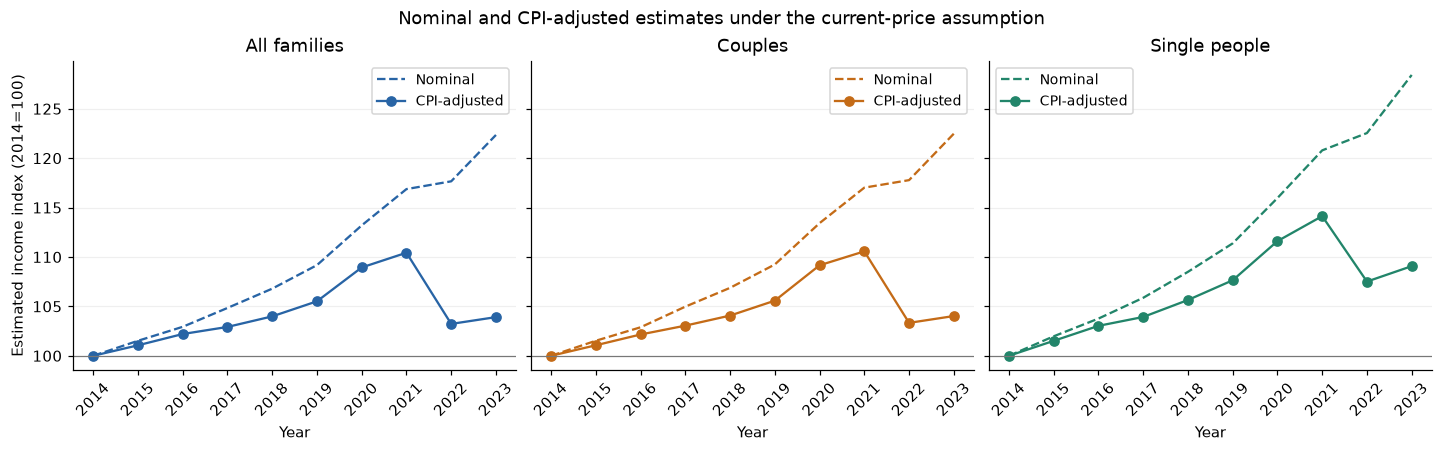

Real annual growth (%),All families,Couples,Single people
Year,,,
2020,3.25,3.39,3.68
2021,1.37,1.29,2.27
2022,-6.52,-6.55,-5.80
2023,0.67,0.67,1.45


In [12]:
real_mean_income = mean_income.mul(cpi.loc["2014"] / cpi, axis=0)
real_annual_growth = real_mean_income.pct_change(fill_method=None) * 100
np.testing.assert_allclose(real_mean_income.loc["2014"], mean_income.loc["2014"])
real_income_summary = pd.DataFrame({
    "2014 income (2014 DKK)": real_mean_income.loc["2014"],
    "2023 income (2014 DKK)": real_mean_income.loc["2023"],
    "Nominal change, 2014–2023 (%)": (mean_income.loc["2023"] / mean_income.loc["2014"] - 1) * 100,
    "Real change, 2014–2023 (%)": (real_mean_income.loc["2023"] / real_mean_income.loc["2014"] - 1) * 100,
    "Real growth in 2022 (%)": real_annual_growth.loc["2022"],
}).rename_axis("Group")
display(real_income_summary.round(2))

nominal_index = mean_income.div(mean_income.loc["2014"], axis=1) * 100
real_income_index = real_mean_income.div(real_mean_income.loc["2014"], axis=1) * 100
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    ax.plot(YEARS, nominal_index[label], linestyle="--", color=COLORS[label], label="Nominal")
    ax.plot(YEARS, real_income_index[label], marker="o", color=COLORS[label], label="CPI-adjusted")
    ax.axhline(100, color="#777777", linewidth=0.8)
    ax.set(title=label, xlabel="Year")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Estimated income index (2014=100)")
fig.suptitle("Nominal and CPI-adjusted estimates under the current-price assumption")
plt.show()
display(real_annual_growth.loc["2020":"2023"].round(2).rename_axis(columns="Real annual growth (%)"))

The annual-average CPI rises **17.74%** between 2014 and 2023. After adjustment,
the baseline estimated mean rises **3.91% for all families**, **4.02% for couples**,
and **9.07% for single people**, compared with nominal increases of 22.35%,
22.48%, and 28.42%. With CPI inflation of approximately **7.70% in 2022**, all
three estimated real means decline that year despite positive nominal growth.

Deflation rescales every representative income in a given year by the same
positive factor, so it **does not change that year's Gini coefficient**.
It also does not change observed membership in the fixed DKK bands. Estimating
the share below an inflation-adjusted threshold would require assumptions about
where incomes lie inside the bands; the municipal analyses retain their
original fixed threshold.

<a id="4-income-inequality"></a>
## 4. Income inequality

### 4.1 Lorenz curves and the grouped-data Gini coefficient

Mean income does not describe how evenly income is distributed. The Lorenz
curve compares the cumulative share of family units with the cumulative share
of estimated income, ordering the bands from lowest to highest income.

For a given group and year, define:

$$
X_i = \frac{\sum_{j=1}^{i} n_j}{\sum_{j=1}^{K} n_j},
\qquad
Y_i = \frac{\sum_{j=1}^{i} n_jm_j}{\sum_{j=1}^{K} n_jm_j},
\qquad X_0=Y_0=0.
$$

The trapezoidal approximation to the Gini coefficient is

$$
\widehat{G} = 1-\sum_{i=1}^{K}(X_i-X_{i-1})(Y_i+Y_{i-1}).
$$

**The origin must be included:** the segment from $(0,0)$ to $(X_1,Y_1)$
contributes to the area under the Lorenz curve. Under the nonnegative-income
model used here, zero indicates equality and values closer to one indicate
greater concentration.

This coefficient treats every family unit in a band as having the same income.
It omits within-band variation and depends on the assumed values for the open
bands. It is therefore a grouped-data approximation, not an official Gini
estimate based on individual or equivalised disposable incomes.

In [13]:
def lorenz_curve(counts, representative_incomes):
    """Compute cumulative family and income shares, including the origin."""
    weights = np.asarray(counts, dtype=float)
    values = np.asarray(representative_incomes, dtype=float)
    if weights.shape != values.shape or weights.ndim != 1:
        raise ValueError("Counts and representative incomes must be matching vectors.")
    if not np.isfinite(weights).all() or not np.isfinite(values).all():
        raise ValueError("Counts and incomes must be finite.")
    if (weights < 0).any() or (values < 0).any():
        raise ValueError("This approximation requires nonnegative counts and incomes.")
    order = np.argsort(values)
    weights, values = weights[order], values[order]
    amounts = weights * values
    if weights.sum() <= 0 or amounts.sum() <= 0:
        raise ValueError("Total count and estimated income must be positive.")
    x = np.r_[0.0, np.cumsum(weights) / weights.sum()]
    y = np.r_[0.0, np.cumsum(amounts) / amounts.sum()]
    return x, y


def grouped_gini(counts, representative_incomes):
    """Return one minus twice the area under the grouped Lorenz curve."""
    x, y = lorenz_curve(counts, representative_incomes)
    return float(1 - np.sum(np.diff(x) * (y[1:] + y[:-1])))


gini = pd.DataFrame({
    label: [grouped_gini(counts[year], BAND_INCOMES) for year in YEARS]
    for label, counts in national_counts.items()
}, index=YEARS).rename_axis("Year")
assert ((gini >= 0) & (gini <= 1)).all().all()
display(gini.round(4))

,All families,Couples,Single people
Year,,,
2014,0.3766,0.2567,0.3283
2015,0.3762,0.2559,0.3296
2016,0.3753,0.2548,0.3294
2017,0.3741,0.2521,0.3282
2018,0.3715,0.2491,0.3261
2019,0.3684,0.2441,0.3239
2020,0.3673,0.2401,0.3252
2021,0.3626,0.2321,0.3232
2022,0.3592,0.2296,0.3176


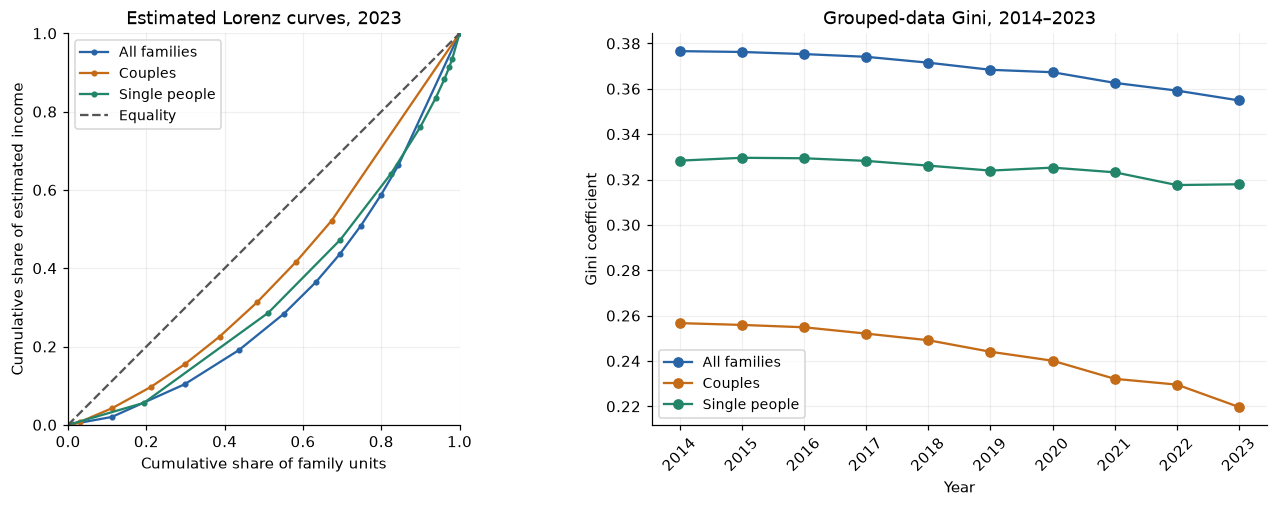

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
for label, counts in national_counts.items():
    x, y = lorenz_curve(counts["2023"], BAND_INCOMES)
    axes[0].plot(x, y, marker="o", markersize=3, label=label, color=COLORS[label])
    axes[1].plot(YEARS, gini[label], marker="o", label=label, color=COLORS[label])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#555555", label="Equality")
axes[0].set(title="Estimated Lorenz curves, 2023", xlabel="Cumulative share of family units",
            ylabel="Cumulative share of estimated income", xlim=(0, 1), ylim=(0, 1))
axes[0].set_aspect("equal")
axes[0].legend(fontsize=9)
axes[1].set(title="Grouped-data Gini, 2014–2023", xlabel="Year", ylabel="Gini coefficient")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=9)
for ax in axes:
    ax.grid(alpha=0.2)
plt.show()

### 4.2 Changes over the period

Under the baseline representative incomes, each group's estimated Gini is lower in 2023 than in 2014. The aggregate
category has the highest Gini of the three series, while couples have the
lowest. The aggregate combines groups with different income levels, so its
inequality also reflects differences between family types.

The table below distinguishes the **absolute change in the coefficient** from
its **relative percentage change**. A decline in this approximation should not
be interpreted as evidence about the distribution of wealth or the full income
distribution within the highest band.

In [15]:
gini_summary = pd.DataFrame({
    "2014 Gini": gini.loc["2014"],
    "2023 Gini": gini.loc["2023"],
    "Absolute change": gini.loc["2023"] - gini.loc["2014"],
    "Relative change (%)": (gini.loc["2023"] / gini.loc["2014"] - 1) * 100,
}).rename_axis("Group")
display(gini_summary.round(4))

,2014 Gini,2023 Gini,Absolute change,Relative change (%)
Group,,,,
All families,0.3766,0.3549,-0.0217,-5.7710
Couples,0.2567,0.2197,-0.0370,-14.4138
Single people,0.3283,0.3179,-0.0104,-3.1727


Couples show the largest relative decline in estimated inequality (**14.41%**),
followed by all families (**5.77%**) and single people (**3.17%**). The endpoint
Gini coefficients are approximately **0.220**, **0.355**, and **0.318**,
respectively.

These changes are conditional on the fixed representative incomes. In
particular, assigning DKK 1.2 million to every unit in the highest band cannot
capture changes in the upper tail.

Section 4.3 tests whether these directions survive alternative open-band assumptions.

<a id="open-band-sensitivity"></a>
### 4.3 Sensitivity to the open income bands

**Purpose.** Test whether the conclusions reflect the observed band counts or
the particular incomes assigned to the two open bands. Evaluate all **12
combinations** of the following fixed representative values:

| Band | Representative incomes tested (DKK) |
| :--- | :--- |
| Below 200,000 | 50,000; **100,000 (baseline)**; 150,000 |
| 1 million and above | 1,000,000; **1,200,000 (baseline)**; 1,500,000; 2,000,000 |

Closed-band values remain unchanged, and each scenario uses the same values in
every year. The lower and upper choices are illustrative stress tests, not
estimated band means or probability distributions. DKK 1 million is the upper
band's lower boundary. The scenarios do not exhaust the possible upper tail,
negative incomes, or time-varying band means.

Recompute both the mean and Gini for every group, year, and scenario. Report
the range of 2023 estimates and the change from 2014 to 2023. These ranges are
**scenario ranges, not confidence intervals**. In the heatmaps, negative values
mean a lower Gini in 2023; positive values mean a higher one. The outlined cell
is the original baseline.

In [16]:
LOWER_SCENARIOS = [50_000, 100_000, 150_000]
UPPER_SCENARIOS = [1_000_000, 1_200_000, 1_500_000, 2_000_000]
sensitivity_records = []
for lower in LOWER_SCENARIOS:
    for upper in UPPER_SCENARIOS:
        representative_values = BAND_INCOMES.copy()
        representative_values.iloc[0] = lower
        representative_values.iloc[-1] = upper
        for label, counts in national_counts.items():
            for year in YEARS:
                sensitivity_records.append({
                    "group": label, "lower_income": lower, "upper_income": upper, "year": year,
                    "mean_income": np.average(representative_values, weights=counts[year]),
                    "gini": grouped_gini(counts[year], representative_values),
                })
sensitivity_results = pd.DataFrame(sensitivity_records)
scenario_keys = ["group", "lower_income", "upper_income"]
start_scenarios = sensitivity_results.loc[sensitivity_results["year"].eq("2014")].drop(columns="year")
end_scenarios = sensitivity_results.loc[sensitivity_results["year"].eq("2023")].drop(columns="year")
sensitivity_endpoints = start_scenarios.merge(end_scenarios, on=scenario_keys, suffixes=("_2014", "_2023"), validate="one_to_one")
sensitivity_endpoints["gini_change"] = sensitivity_endpoints["gini_2023"] - sensitivity_endpoints["gini_2014"]
sensitivity_endpoints["mean_growth_pct"] = 100 * (sensitivity_endpoints["mean_income_2023"] / sensitivity_endpoints["mean_income_2014"] - 1)
sensitivity_summary = sensitivity_endpoints.groupby("group").agg(
    mean_2023_min=("mean_income_2023", "min"), mean_2023_max=("mean_income_2023", "max"),
    gini_2023_min=("gini_2023", "min"), gini_2023_max=("gini_2023", "max"),
    gini_change_min=("gini_change", "min"), gini_change_max=("gini_change", "max"),
    declining_gini_scenarios=("gini_change", lambda s: int((s < 0).sum())),
).reindex(GROUPS.values())
display(sensitivity_summary[["mean_2023_min", "mean_2023_max"]].round(0).astype(int).rename(
    columns={"mean_2023_min": "Min. 2023 mean (DKK)", "mean_2023_max": "Max. 2023 mean (DKK)"}
).rename_axis("Group"))
display(sensitivity_summary.drop(columns=["mean_2023_min", "mean_2023_max"]).rename(columns={
    "gini_2023_min": "Min. 2023 Gini", "gini_2023_max": "Max. 2023 Gini",
    "gini_change_min": "Min. Gini change", "gini_change_max": "Max. Gini change",
    "declining_gini_scenarios": "Gini declines (of 12)",
}).round(4).rename_axis("Group"))

# The original assumptions must reproduce the original estimates exactly.
baseline_scenarios = sensitivity_results.loc[
    sensitivity_results["lower_income"].eq(100_000) & sensitivity_results["upper_income"].eq(1_200_000)
]
for label in GROUPS.values():
    baseline = baseline_scenarios.loc[baseline_scenarios["group"].eq(label)].set_index("year").reindex(YEARS)
    np.testing.assert_allclose(baseline["mean_income"], mean_income[label])
    np.testing.assert_allclose(baseline["gini"], gini[label])

,Min. 2023 mean (DKK),Max. 2023 mean (DKK)
Group,,
All families,519589,686849
Couples,753839,1081744
Single people,331632,369995


,Min. 2023 Gini,Max. 2023 Gini,Min. Gini change,Max. Gini change,Gini declines (of 12)
Group,,,,,
All families,0.3130,0.4555,-0.0447,0.0154,9
Couples,0.1796,0.3300,-0.0489,-0.0179,12
Single people,0.2797,0.3777,-0.0481,0.0305,7


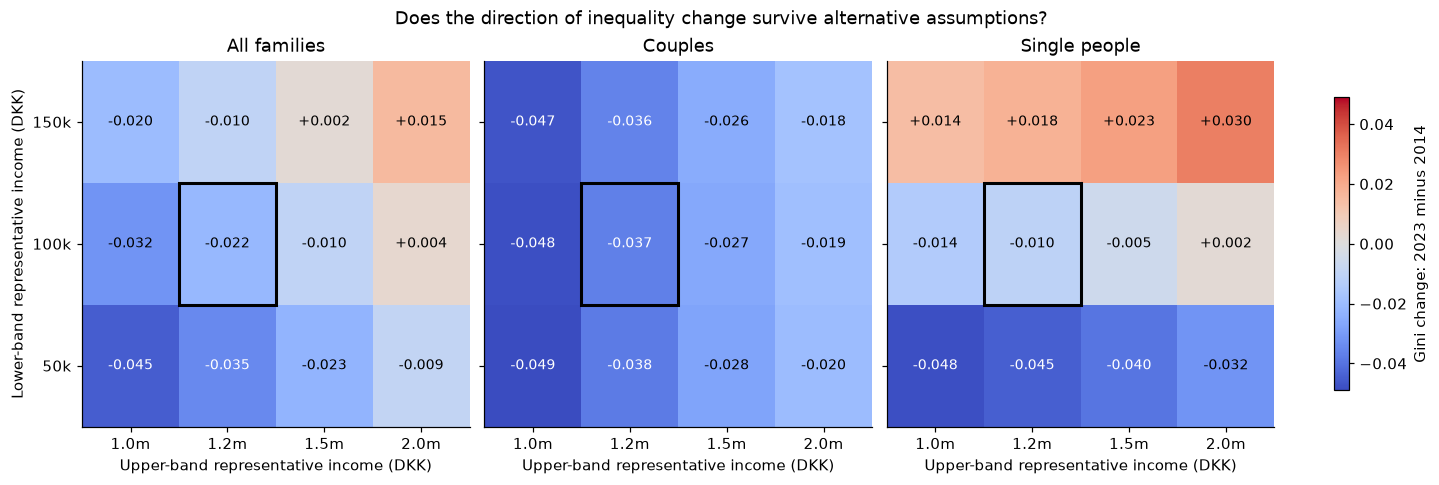

In [17]:
delta_limit = sensitivity_endpoints["gini_change"].abs().max()
sensitivity_norm = TwoSlopeNorm(vmin=-delta_limit, vcenter=0, vmax=delta_limit)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=True, layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    matrix = sensitivity_endpoints.loc[sensitivity_endpoints["group"].eq(label)].pivot(
        index="lower_income", columns="upper_income", values="gini_change"
    ).reindex(index=LOWER_SCENARIOS, columns=UPPER_SCENARIOS)
    mesh = ax.imshow(matrix, origin="lower", cmap="coolwarm", norm=sensitivity_norm, aspect="auto")
    ax.set_xticks(range(4), ["1.0m", "1.2m", "1.5m", "2.0m"])
    ax.set_yticks(range(3), ["50k", "100k", "150k"])
    ax.set(title=label, xlabel="Upper-band representative income (DKK)")
    for row in range(3):
        for col in range(4):
            value = matrix.iloc[row, col]
            ax.text(col, row, f"{value:+.3f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(value) > 0.7 * delta_limit else "black")
    ax.add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))
axes[0].set_ylabel("Lower-band representative income (DKK)")
fig.colorbar(mesh, ax=list(axes), label="Gini change: 2023 minus 2014", shrink=0.8)
fig.suptitle("Does the direction of inequality change survive alternative assumptions?")
plt.show()

The direction is **not robust across all tested scenarios** for all families
or single people: their Gini changes range from approximately **−0.045 to +0.015**
and **−0.048 to +0.030**, respectively. Couples show a decline in every tested
scenario, ranging from approximately **−0.049 to −0.018**.

Consequently, the baseline declines for all families and single people should
not be presented as unconditional evidence that inequality fell. The couples'
result is more stable within this grid, but the exercise does not establish
robustness to all possible band means or within-band distributions.

<a id="5-income-and-inequality"></a>
## 5. Income and inequality

### 5.1 Correlations in levels

For each group, Pearson's correlation measures the linear association between
the ten annual estimates of mean income and the ten Gini coefficients:

$$
r = \frac{\sum_t(\widehat{\mu}_t-\overline{\mu})(\widehat{G}_t-\overline{G})}
{\sqrt{\sum_t(\widehat{\mu}_t-\overline{\mu})^2}
 \sqrt{\sum_t(\widehat{G}_t-\overline{G})^2}}.
$$

The two series are aligned by year before calculation. There are only ten
observations per group, and both quantities are derived from the same counts
and representative incomes. This is a descriptive comparison, not a test of
whether income growth causes inequality to fall.

,Pearson r,Annual observations
Group,,
All families,-0.9872,10
Couples,-0.9910,10
Single people,-0.9331,10


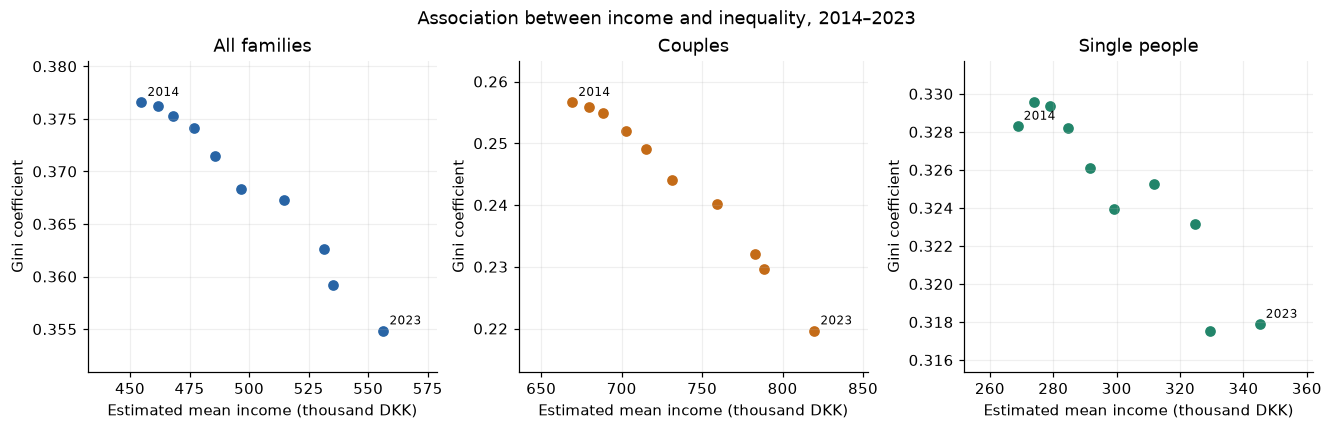

In [18]:
correlations = pd.DataFrame({
    "Pearson r": {label: mean_income[label].corr(gini[label]) for label in GROUPS.values()},
    "Annual observations": len(YEARS),
}).rename_axis("Group")
display(correlations.round(4))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    ax.scatter(mean_income[label] / 1_000, gini[label], color=COLORS[label])
    for year in ["2014", "2023"]:
        ax.annotate(year, (mean_income.loc[year, label] / 1_000, gini.loc[year, label]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set(title=label, xlabel="Estimated mean income (thousand DKK)", ylabel="Gini coefficient")
    ax.margins(x=0.22, y=0.18)
    ax.grid(alpha=0.2)
fig.suptitle("Association between income and inequality, 2014–2023")
plt.show()

The correlations are strongly negative: approximately **−0.987** for all
families, **−0.991** for couples, and **−0.933** for single people. Within this
period and model, years with higher estimated mean income tend to have lower
estimated inequality.

Common time trends and the shared construction of the two indicators can
contribute to this association. The correlations do not establish a general
economic relationship, statistical independence across years, or causality.

<a id="annual-change-correlation"></a>
### 5.2 Do annual changes move together?

**Purpose.** Two trending series can have a strong correlation in levels even
when their year-to-year movements are weakly related. Compare each change in
estimated mean income with the Gini change over the **same annual interval**:

$$\Delta\mu_t=\mu_t-\mu_{t-1},\qquad
\Delta G_t=G_t-G_{t-1},\qquad t=2015,\ldots,2023.$$

Calculate Pearson correlations for nominal income changes and, separately,
CPI-adjusted income changes. These are changes in DKK and in the Gini coefficient,
not percentage growth rates. There are **nine pairs** for changes, compared
with ten for levels. First differencing can reduce the influence of shared trends;
it does not establish stationarity, independence, or causality.

With such a short series, check how much the nominal-change correlation moves
when any one annual pair is omitted. The resulting minimum and maximum are
**leave-one-out diagnostics, not confidence intervals**. No significance tests
are reported under an unsupported independent-observations assumption.

,Nominal levels r (n=10),Nominal changes r (n=9),Real changes r (n=9),Leave-one-out min. (n=8),Leave-one-out max. (n=8)
Group,,,,,
All families,-0.987,-0.432,0.276,-0.666,-0.216
Couples,-0.991,-0.819,-0.168,-0.937,-0.692
Single people,-0.933,0.337,0.785,0.121,0.525


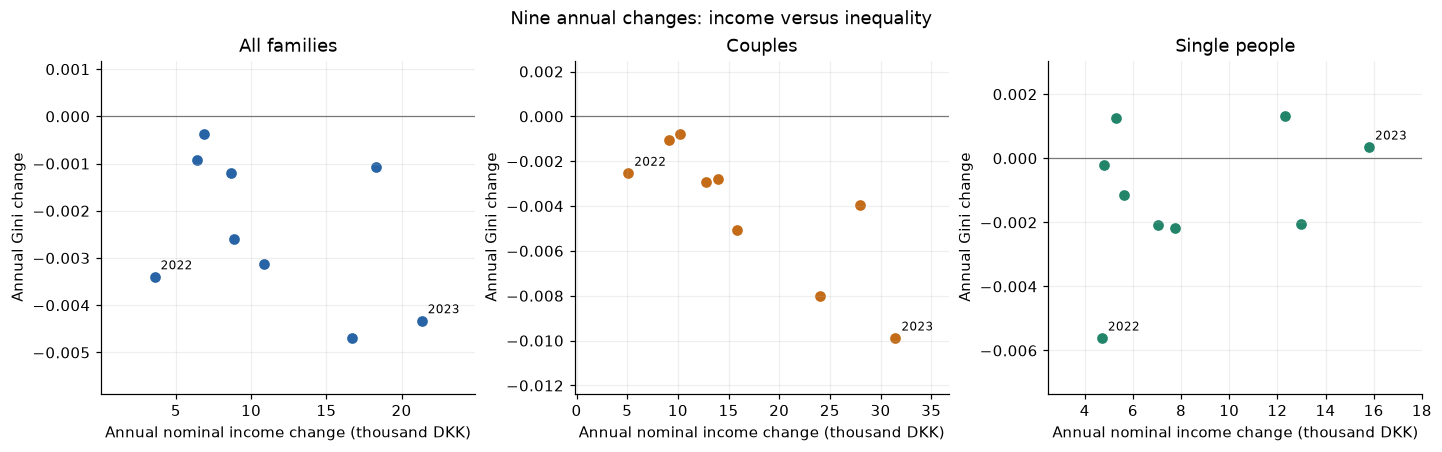

In [19]:
nominal_income_changes = mean_income.diff().iloc[1:]
real_income_changes = real_mean_income.diff().iloc[1:]
gini_changes = gini.diff().iloc[1:]
assert nominal_income_changes.index.equals(gini_changes.index)
assert real_income_changes.index.equals(gini_changes.index)
change_correlations = pd.DataFrame({
    "Nominal levels r (n=10)": correlations["Pearson r"],
    "Nominal changes r (n=9)": nominal_income_changes.corrwith(gini_changes),
    "Real changes r (n=9)": real_income_changes.corrwith(gini_changes),
}).reindex(GROUPS.values()).rename_axis("Group")

leave_one_out_records = []
for label in GROUPS.values():
    for omitted_year in YEARS[1:]:
        leave_one_out_records.append({
            "group": label, "omitted_change_ending_in": omitted_year,
            "r": nominal_income_changes[label].drop(omitted_year).corr(gini_changes[label].drop(omitted_year)),
        })
leave_one_out = pd.DataFrame(leave_one_out_records)
loo_summary = leave_one_out.groupby("group")["r"].agg(["min", "max"]).reindex(GROUPS.values())
change_correlations["Leave-one-out min. (n=8)"] = loo_summary["min"]
change_correlations["Leave-one-out max. (n=8)"] = loo_summary["max"]
display(change_correlations.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    ax.scatter(nominal_income_changes[label] / 1_000, gini_changes[label], color=COLORS[label])
    for year in ["2022", "2023"]:
        ax.annotate(year, (nominal_income_changes.loc[year, label] / 1_000, gini_changes.loc[year, label]),
                    xytext=(4, 5), textcoords="offset points", fontsize=8)
    ax.axhline(0, color="#777777", linewidth=0.8)
    ax.set(title=label, xlabel="Annual nominal income change (thousand DKK)", ylabel="Annual Gini change")
    ax.margins(x=0.2, y=0.25)
    ax.grid(alpha=0.2)
fig.suptitle("Nine annual changes: income versus inequality")
plt.show()

Using nominal annual changes, the correlations are approximately **−0.432** for
all families, **−0.819** for couples, and **+0.337** for single people. Thus the
strong negative correlations in levels do not carry over uniformly to changes;
the single-people association reverses sign.

Using CPI-adjusted changes produces correlations of approximately **+0.276**,
**−0.168**, and **+0.785**, respectively. This variation across specifications
reinforces a descriptive interpretation. Shared measurement assumptions, short
time series, and individual annual movements matter; these results do not show
that income growth either causes or prevents inequality.

<a id="6-copenhagen"></a>
## 6. Copenhagen

### 6.1 Share of family units in the lowest income band

The next analysis uses observed counts directly and does not require midpoint
assumptions. For each family category in Copenhagen, calculate

$$
s_t = 100\,
\frac{\text{family units with income below DKK 200,000 in year }t}
{\text{total family units in the same category and year}}.
$$

This is the share below a fixed income-band boundary. It is **not an official
poverty rate**: the threshold is not adjusted for prices, family size, or the
overall income distribution. The records are annual aggregates, so the data
also cannot follow the same families over time.

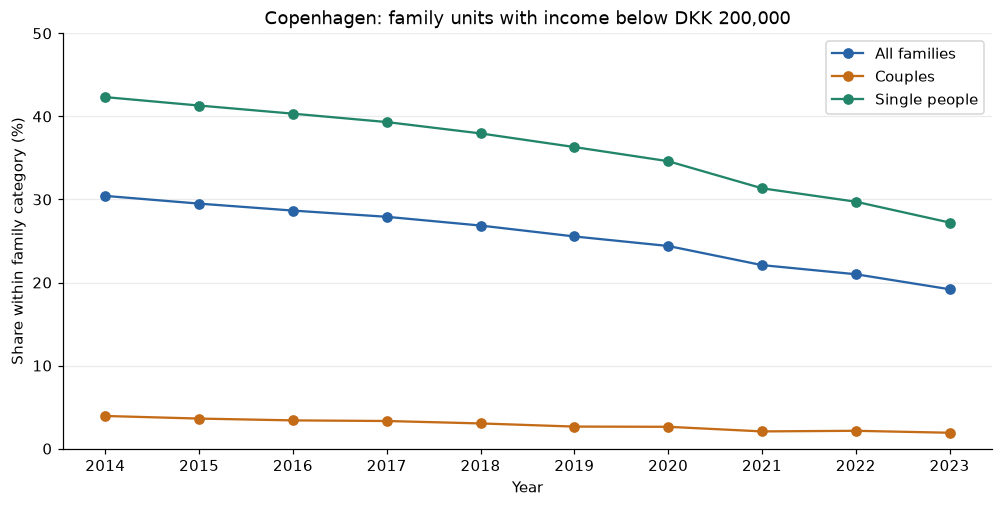

,2014 (%),2023 (%),Change (percentage points)
Group,,,
All families,30.43,19.19,-11.24
Couples,3.93,1.91,-2.02
Single people,42.32,27.22,-15.10


In [20]:
def lowest_band_share(place):
    """Return annual lowest-band percentages using each group's own denominator."""
    shares = {}
    for family_type, label in GROUPS.items():
        block = income.loc[
            income["place"].eq(place) & income["family_type"].eq(family_type)
        ].set_index("income_band")[YEARS]
        shares[label] = 100 * block.loc[LOWEST_BAND] / block.loc["Total"]
    return pd.DataFrame(shares).rename_axis("Year")


copenhagen_shares = lowest_band_share("Copenhagen")
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for label in GROUPS.values():
    ax.plot(YEARS, copenhagen_shares[label], marker="o", color=COLORS[label], label=label)
ax.set(title="Copenhagen: family units with income below DKK 200,000",
       xlabel="Year", ylabel="Share within family category (%)", ylim=(0, 50))
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.show()

copenhagen_summary = pd.DataFrame({
    "2014 (%)": copenhagen_shares.loc["2014"],
    "2023 (%)": copenhagen_shares.loc["2023"],
    "Change (percentage points)": copenhagen_shares.loc["2023"] - copenhagen_shares.loc["2014"],
}).rename_axis("Group")
display(copenhagen_summary.round(2))

The lowest-band share declines from **30.43% to 19.19%** for all families,
from **3.93% to 1.91%** for couples, and from **42.32% to 27.22%** for single
people. These are decreases of **11.24**, **2.02**, and **15.10 percentage
points**, respectively.

Single people record the largest decline, while their endpoint share remains
higher than those of the other categories. A falling share below a fixed threshold does not by itself show that the same
families became better off in real terms: inflation and changes in the
composition of the population can also affect this measure.

<a id="7-municipal-comparisons"></a>
## 7. Municipal comparisons

### 7.1 Geographic context and coverage

The income dataset covers **98 municipalities**, rather than 98 individual
cities. The boundary file contains five regions and is used only as a backdrop.
Each municipal value is displayed at the coordinates of a same-named settlement
from `dk.json`; these markers are illustrative locations, not municipal
centroids or municipal boundaries.

Names are matched after trimming whitespace and normalizing case. Coverage is
checked explicitly before plotting so that unmatched or duplicate locations
cannot silently disappear from the maps. Coordinates are read as longitude and
latitude in WGS 84 and projected together with the backdrop for display.

Coordinate matches: 98 of 98 municipalities.


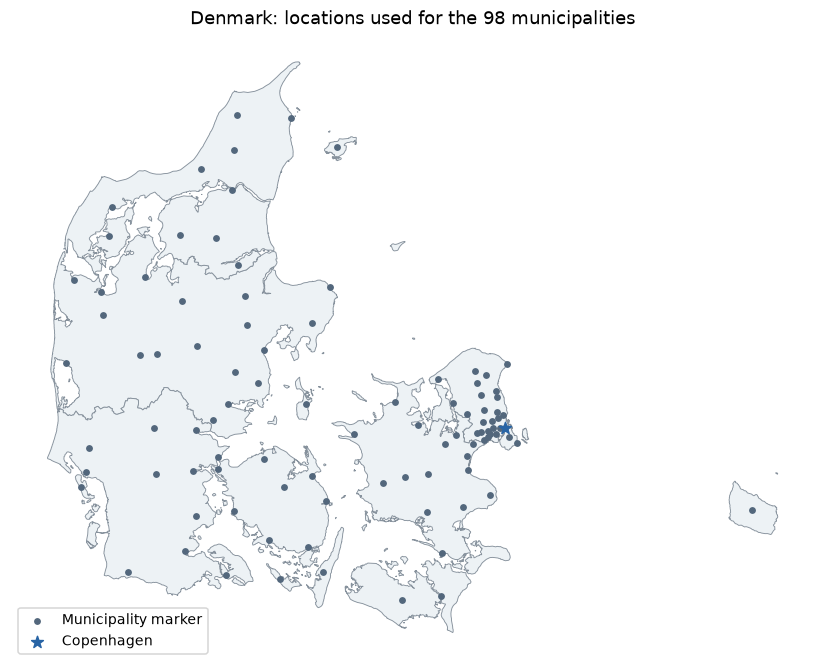

In [21]:
regions = gpd.read_file(DATA_DIR / "gadm41_DNK_1.json")
with (DATA_DIR / "dk.json").open(encoding="utf-8") as file:
    settlements = pd.DataFrame(json.load(file))

settlements["place_key"] = settlements["city"].str.strip().str.casefold()
settlements["lat"] = pd.to_numeric(settlements["lat"], errors="raise")
settlements["lng"] = pd.to_numeric(settlements["lng"], errors="raise")
assert settlements["place_key"].is_unique, "Settlement names need disambiguation."

locations = municipal[["place"]].drop_duplicates().copy()
locations["place_key"] = locations["place"].str.strip().str.casefold()
locations = locations.merge(
    settlements[["place_key", "lat", "lng"]], on="place_key", how="left", validate="one_to_one"
)
assert locations[["lat", "lng"]].notna().all().all(), "Some municipalities have no coordinates."
assert locations["lat"].between(-90, 90).all() and locations["lng"].between(-180, 180).all()
municipality_points = gpd.GeoDataFrame(
    locations,
    geometry=gpd.points_from_xy(locations["lng"], locations["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:25832")
map_regions = regions.to_crs(municipality_points.crs)
print(f"Coordinate matches: {len(municipality_points)} of {municipal['place'].nunique()} municipalities.")

fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
map_regions.plot(ax=ax, facecolor="#EDF2F5", edgecolor="#87929D", linewidth=0.6)
municipality_points.plot(ax=ax, color="#53677C", markersize=12, label="Municipality marker")
municipality_points.loc[municipality_points["place"].eq("Copenhagen")].plot(
    ax=ax, color=COLORS["All families"], markersize=65, marker="*", label="Copenhagen"
)
ax.set_title("Denmark: locations used for the 98 municipalities")
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=9)
plt.show()

### 7.2 Lowest-band shares by family category in 2023

For each municipality and category, divide the lowest-band count by the
corresponding total. The merge uses the municipality and family type explicitly,
so the result does not depend on the order of rows in the CSV.

The three maps use a **common color scale**. This makes colors comparable across
groups, even though the small shares for couples produce less visible variation.
The accompanying table identifies each category's maximum using all 98
municipalities.

In [22]:
join_keys = ["place", "family_type"]
totals_2023 = municipal.loc[municipal["income_band"].eq("Total"), join_keys + ["2023"]].rename(
    columns={"2023": "total_count"}
)
lowest_2023 = municipal.loc[municipal["income_band"].eq(LOWEST_BAND), join_keys + ["2023"]].rename(
    columns={"2023": "lowest_band_count"}
)
municipal_shares = totals_2023.merge(lowest_2023, on=join_keys, validate="one_to_one")
municipal_shares["share_pct"] = 100 * municipal_shares["lowest_band_count"] / municipal_shares["total_count"]
municipal_shares["group"] = municipal_shares["family_type"].map(GROUPS)
assert len(municipal_shares) == 98 * 3
assert municipal_shares["share_pct"].between(0, 100).all()

group_maxima = municipal_shares.loc[municipal_shares.groupby("group")["share_pct"].idxmax()]
display(group_maxima.set_index("group").reindex(GROUPS.values())[
    ["place", "lowest_band_count", "total_count", "share_pct"]
].rename(columns={
    "place": "Municipality", "lowest_band_count": "Lowest-band count",
    "total_count": "Total count", "share_pct": "Share (%)",
}).round(2))

,Municipality,Lowest-band count,Total count,Share (%)
group,,,,
All families,Aarhus,40549.0,205977.0,19.69
Couples,Ærø,51.0,1439.0,3.54
Single people,Aarhus,39343.0,127284.0,30.91


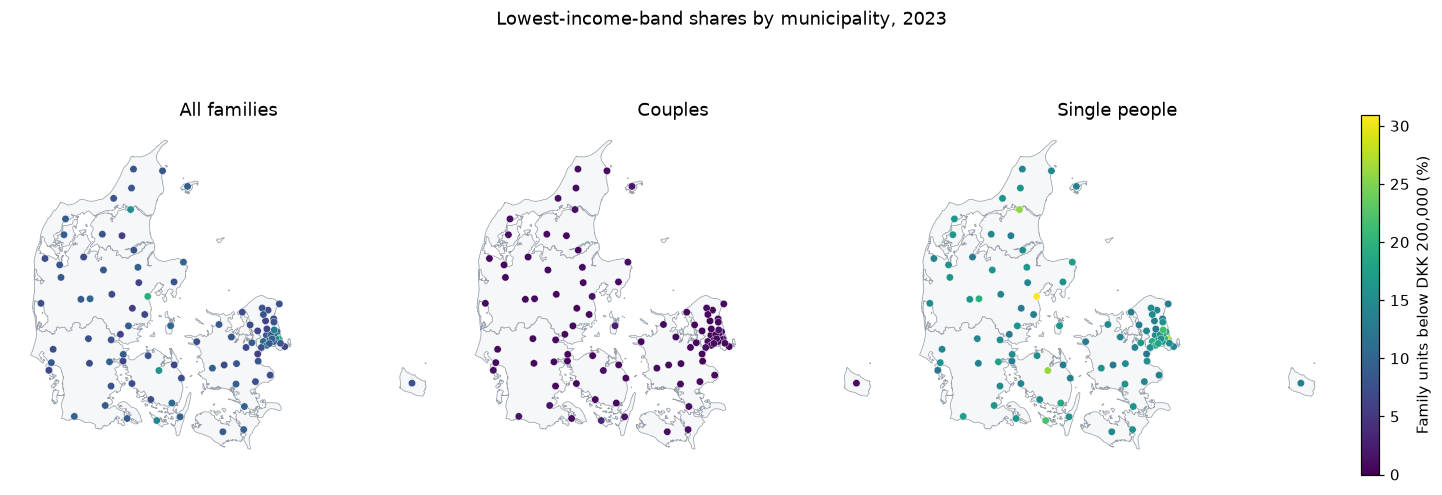

In [23]:
shared_norm = Normalize(vmin=0, vmax=municipal_shares["share_pct"].max())
fig, axes = plt.subplots(1, 3, figsize=(13, 5), layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    values = municipal_shares.loc[municipal_shares["group"].eq(label), ["place", "share_pct"]]
    points = municipality_points.merge(values, on="place", validate="one_to_one")
    map_regions.plot(ax=ax, facecolor="#F6F7F8", edgecolor="#9AA3AD", linewidth=0.5)
    points.plot(ax=ax, column="share_pct", cmap="viridis", norm=shared_norm,
                markersize=23, edgecolor="white", linewidth=0.25)
    ax.set_title(label)
    ax.set_axis_off()
fig.colorbar(ScalarMappable(norm=shared_norm, cmap="viridis"), ax=list(axes),
             label="Family units below DKK 200,000 (%)", shrink=0.7, pad=0.02)
fig.suptitle("Lowest-income-band shares by municipality, 2023")
plt.show()

**Aarhus** has the highest lowest-band share for all families (**19.69%**) and
single people (**30.91%**). For couples, the maximum is in **Ærø (3.54%)**,
where the numerator is only 51 family units. Including counts helps put
percentages from differently sized municipalities into context.

The dataset has no information on age, student status, employment, or family
size within these categories. Explanations based on those characteristics would
therefore need additional data.

### 7.3 The aggregate: shares and counts answer different questions

The `Families, total` category already includes couples and single people.
Use that category directly for an overall municipal comparison: adding all
three categories together would double-count the same family units.

The highest **share** identifies the municipality where the lowest band is most
prevalent. The highest **count** identifies the municipality with the largest
number of family units in that band. These need not be the same municipality.

In [24]:
all_family_shares = municipal_shares.loc[municipal_shares["group"].eq("All families")].copy()
ranked_shares = all_family_shares.sort_values("share_pct", ascending=False).reset_index(drop=True)
highest_share = ranked_shares.iloc[0]
second_share = ranked_shares.iloc[1]
highest_count = all_family_shares.loc[all_family_shares["lowest_band_count"].idxmax()]

print(f"Highest share: {highest_share['place']} ({highest_share['share_pct']:.2f}%).")
print(f"Second-highest share: {second_share['place']} ({second_share['share_pct']:.2f}%).")
print(f"Gap: {highest_share['share_pct'] - second_share['share_pct']:.2f} percentage points.")
print(f"Largest count: {highest_count['place']} ({highest_count['lowest_band_count']:,.0f} family units).")
display(ranked_shares.head(10)[["place", "lowest_band_count", "total_count", "share_pct"]].rename(
    columns={"place": "Municipality", "lowest_band_count": "Lowest-band count",
             "total_count": "Total count", "share_pct": "Share (%)"}
).round(2))

Highest share: Aarhus (19.69%).
Second-highest share: Copenhagen (19.19%).
Gap: 0.50 percentage points.
Largest count: Copenhagen (74,540 family units).


,Municipality,Lowest-band count,Total count,Share (%)
0,Aarhus,40549.0,205977.0,19.69
1,Copenhagen,74540.0,388467.0,19.19
2,Odense,18438.0,115055.0,16.03
3,Aalborg,18790.0,122416.0,15.35
4,Ærø,513.0,3542.0,14.48
5,Frederiksberg,8250.0,60701.0,13.59
6,Lyngby-Taarbæk,3825.0,29654.0,12.90
7,Albertslund,1701.0,14024.0,12.13
8,Brøndby,2292.0,19845.0,11.55
9,Ishøj,1338.0,11814.0,11.33


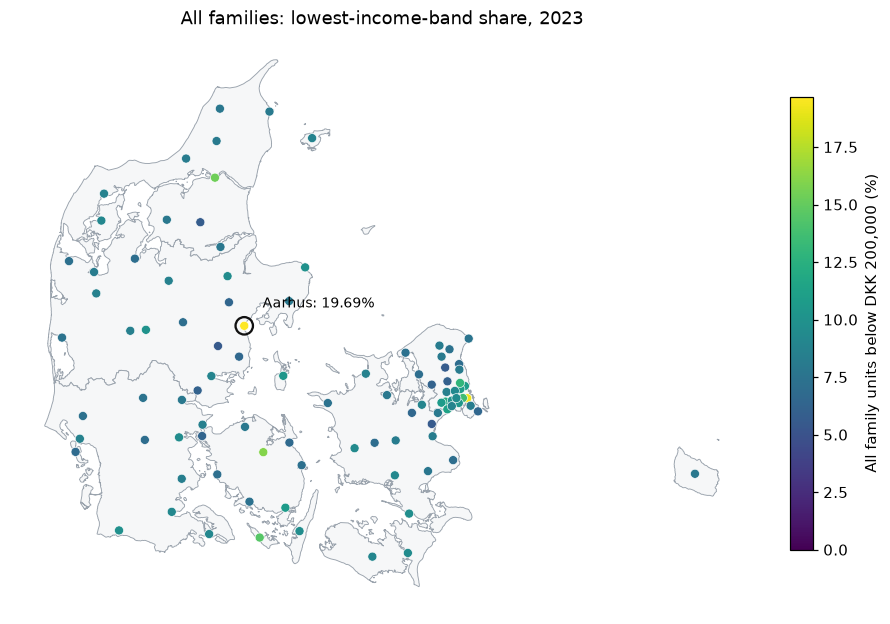

In [25]:
points = municipality_points.merge(
    all_family_shares[["place", "share_pct"]], on="place", validate="one_to_one"
)
norm = Normalize(vmin=0, vmax=all_family_shares["share_pct"].max())
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
map_regions.plot(ax=ax, facecolor="#F6F7F8", edgecolor="#9AA3AD", linewidth=0.6)
points.plot(ax=ax, column="share_pct", cmap="viridis", norm=norm,
            markersize=35, edgecolor="white", linewidth=0.4)
top_point = points.loc[points["place"].eq(highest_share["place"])].iloc[0]
ax.scatter(top_point.geometry.x, top_point.geometry.y, facecolors="none",
           edgecolors="#111111", linewidths=1.5, s=130)
ax.annotate(f"{highest_share['place']}: {highest_share['share_pct']:.2f}%",
            (top_point.geometry.x, top_point.geometry.y), xytext=(12, 12),
            textcoords="offset points", fontsize=9)
fig.colorbar(ScalarMappable(norm=norm, cmap="viridis"), ax=ax,
             label="All family units below DKK 200,000 (%)", shrink=0.7)
ax.set_title("All families: lowest-income-band share, 2023")
ax.set_axis_off()
plt.show()

### 7.4 Comparing the full municipal distribution

A ranked bar chart makes small differences easier to assess than a map. All 98
municipalities are shown below in two consecutive rank ranges, with a shared
percentage scale. Aarhus and Copenhagen are highlighted; the dashed line marks
the national share, calculated from national counts rather than by taking an
unweighted average of municipal percentages.

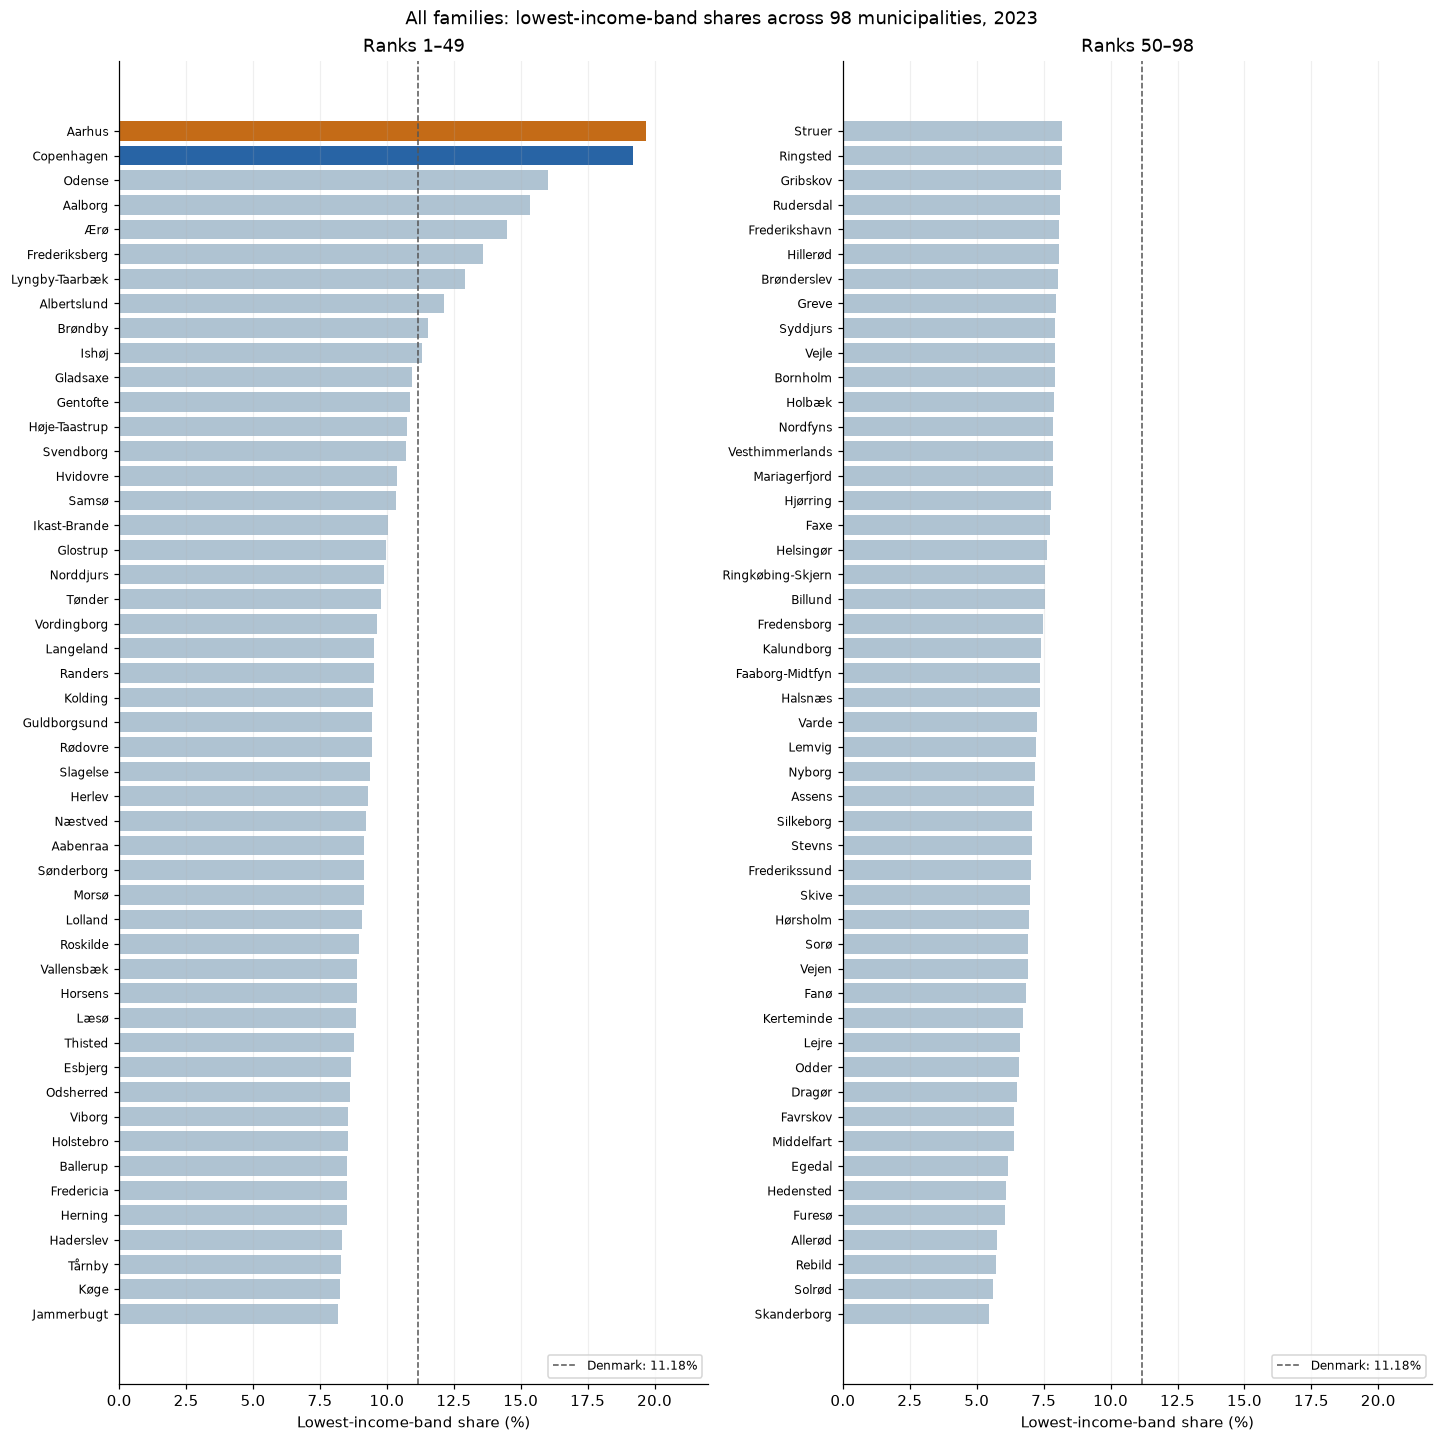

In [26]:
national_share_2023 = lowest_band_share("All Denmark").loc["2023", "All families"]
fig, axes = plt.subplots(1, 2, figsize=(13, 13), sharex=True, layout="constrained")
for ax, start in zip(axes, [0, 49]):
    subset = ranked_shares.iloc[start:start + 49]
    bar_colors = [
        "#C46B17" if place == highest_share["place"]
        else "#2864A5" if place == second_share["place"] else "#AFC3D2"
        for place in subset["place"]
    ]
    ax.barh(subset["place"], subset["share_pct"], color=bar_colors)
    ax.invert_yaxis()
    ax.axvline(national_share_2023, color="#555555", linestyle="--", linewidth=1,
               label=f"Denmark: {national_share_2023:.2f}%")
    ax.set(title=f"Ranks {start + 1}–{start + len(subset)}", xlabel="Lowest-income-band share (%)")
    ax.set_xlim(0, 22)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.2)
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("All families: lowest-income-band shares across 98 municipalities, 2023")
plt.show()

Aarhus leads Copenhagen by only **0.50 percentage points**: **19.69%** versus
**19.19%**. Copenhagen nevertheless has the largest absolute count, with
**74,540** family units in the lowest band, compared with **40,549** in Aarhus.

The municipality with the highest share should therefore not be described as
having the largest number of low-income family units, and this band-based
ranking should not be presented as a ranking of official poverty rates.

<a id="municipal-evolution"></a>
### 7.5 How did municipalities change between 2014 and 2023?

**Purpose.** A 2023 ranking gives a snapshot, whereas the full period shows
whether municipalities followed similar paths. Build a balanced panel of
**98 municipalities × 3 categories × 10 years**, always dividing the lowest-band
count by the total for the same municipality, category, and year.

For municipality $m$ and group $g$, the endpoint change is

$$\Delta s_{m,g}=s_{m,g,2023}-s_{m,g,2014}.$$

It is measured in **percentage points**: negative values indicate a smaller
lowest-band share. Keep the endpoint counts alongside percentages to preserve
information about municipal size.

Rank 1 denotes the **highest** share within each category and year. Define the
rank change as $R_{2023}-R_{2014}$: a positive number means a move to a lower
position in that ranking. Ties receive the same minimum rank. Rank movements
are relative: a municipality can fall in share and still move closer to rank 1
if other municipalities fall more. They are not measures of causal policy success.

In [27]:
panel_keys = ["place", "family_type", "year"]
municipal_long = municipal.melt(
    id_vars=["place", "family_type", "income_band"], value_vars=YEARS,
    var_name="year", value_name="count",
)
panel_totals = municipal_long.loc[municipal_long["income_band"].eq("Total"), panel_keys + ["count"]].rename(columns={"count": "total_count"})
panel_lowest = municipal_long.loc[municipal_long["income_band"].eq(LOWEST_BAND), panel_keys + ["count"]].rename(columns={"count": "lowest_band_count"})
municipal_panel = panel_totals.merge(panel_lowest, on=panel_keys, validate="one_to_one")
assert len(municipal_panel) == 98 * 3 * 10
assert municipal_panel[["total_count", "lowest_band_count"]].notna().all().all()
assert (municipal_panel["total_count"] > 0).all()
municipal_panel["group"] = municipal_panel["family_type"].map(GROUPS)
municipal_panel["share_pct"] = 100 * municipal_panel["lowest_band_count"] / municipal_panel["total_count"]
municipal_panel["rank"] = municipal_panel.groupby(["group", "year"])["share_pct"].rank(ascending=False, method="min").astype(int)
assert municipal_panel["share_pct"].between(0, 100).all()

endpoint_keys = ["place", "group"]
endpoint_values = ["share_pct", "rank", "lowest_band_count", "total_count"]
municipal_change = municipal_panel.loc[municipal_panel["year"].eq("2014"), endpoint_keys + endpoint_values].merge(
    municipal_panel.loc[municipal_panel["year"].eq("2023"), endpoint_keys + endpoint_values],
    on=endpoint_keys, suffixes=("_2014", "_2023"), validate="one_to_one",
)
municipal_change["change_pp"] = municipal_change["share_pct_2023"] - municipal_change["share_pct_2014"]
municipal_change["rank_change"] = municipal_change["rank_2023"] - municipal_change["rank_2014"]

extreme_rows = []
for label in GROUPS.values():
    group_changes = municipal_change.loc[municipal_change["group"].eq(label)]
    upper_description = "Largest increase" if group_changes["change_pp"].max() > 0 else "Smallest decrease"
    for description, idx in [("Largest decrease", group_changes["change_pp"].idxmin()),
                             (upper_description, group_changes["change_pp"].idxmax())]:
        row = group_changes.loc[idx].copy()
        row["Comparison"] = description
        extreme_rows.append(row)
municipal_extremes = pd.DataFrame(extreme_rows)
display(municipal_extremes[["group", "Comparison", "place", "share_pct_2014", "share_pct_2023", "change_pp"]].rename(columns={
    "group": "Group", "place": "Municipality", "share_pct_2014": "2014 (%)",
    "share_pct_2023": "2023 (%)", "change_pp": "Change (pp)",
}).round(2).reset_index(drop=True))

largest_family_decreases = municipal_change.loc[municipal_change["group"].eq("All families")].nsmallest(10, "change_pp")
display(largest_family_decreases[["place", "share_pct_2014", "share_pct_2023", "change_pp", "rank_2014", "rank_2023"]].rename(columns={
    "place": "Municipality", "share_pct_2014": "2014 (%)", "share_pct_2023": "2023 (%)",
    "change_pp": "Change (pp)", "rank_2014": "2014 rank", "rank_2023": "2023 rank",
}).round(2).reset_index(drop=True))

rank_movers = municipal_change.assign(abs_rank_change=municipal_change["rank_change"].abs()).sort_values(
    ["abs_rank_change", "place"], ascending=[False, True]
).groupby("group", sort=False).head(3)
rank_movers = pd.concat([rank_movers.loc[rank_movers["group"].eq(label)] for label in GROUPS.values()])
display(rank_movers[["group", "place", "rank_2014", "rank_2023", "rank_change", "change_pp"]].rename(columns={
    "group": "Group", "place": "Municipality", "rank_2014": "2014 rank", "rank_2023": "2023 rank",
    "rank_change": "Rank change", "change_pp": "Share change (pp)",
}).round(2).reset_index(drop=True))

,Group,Comparison,Municipality,2014 (%),2023 (%),Change (pp)
0,All families,Largest decrease,Læsø,22.68,8.84,-13.84
1,All families,Smallest decrease,Allerød,8.42,5.75,-2.67
2,Couples,Largest decrease,Copenhagen,3.93,1.91,-2.02
3,Couples,Largest increase,Ærø,2.14,3.54,1.41
4,Single people,Largest decrease,Læsø,39.28,13.76,-25.52
5,Single people,Smallest decrease,Allerød,20.17,13.20,-6.97


,Municipality,2014 (%),2023 (%),Change (pp),2014 rank,2023 rank
0,Læsø,22.68,8.84,-13.84,7,37
1,Lolland,20.67,9.05,-11.61,10,33
2,Copenhagen,30.43,19.19,-11.24,1,2
3,Langeland,20.76,9.54,-11.23,9,22
4,Samsø,21.06,10.32,-10.74,8,16
5,Norddjurs,20.20,9.90,-10.30,11,19
6,Bornholm,18.16,7.91,-10.25,17,60
7,Ærø,24.53,14.48,-10.04,4,5
8,Frederiksberg,23.62,13.59,-10.03,6,6
9,Morsø,19.09,9.13,-9.96,14,32


,Group,Municipality,2014 rank,2023 rank,Rank change,Share change (pp)
0,All families,Vallensbæk,89,35,-54,-2.80
1,All families,Skive,36,81,45,-9.89
2,All families,Bornholm,17,60,43,-10.25
3,Couples,Fanø,83,12,-71,0.22
4,Couples,Lemvig,26,76,50,-1.12
5,Couples,Vallensbæk,84,34,-50,-0.12
6,Single people,Læsø,6,75,69,-25.52
7,Single people,Vallensbæk,84,17,-67,-7.99
8,Single people,Brøndby,75,11,-64,-8.31


The change maps use a **shared scale centered on zero**: blue represents a
decrease and red an increase in the lowest-band share. Marker sizes are fixed,
so map symbols encode neither population nor the size of the numerator.

The time-series panels then use all ten years. The shaded band is the
interquartile range of the **98 municipal percentages, with equal weight per
municipality**; it describes geographic dispersion, not statistical uncertainty.
The national line is calculated from national counts and is not an unweighted
average of municipal percentages. Copenhagen and Aarhus are shown because they
were already the case studies in the preceding sections.

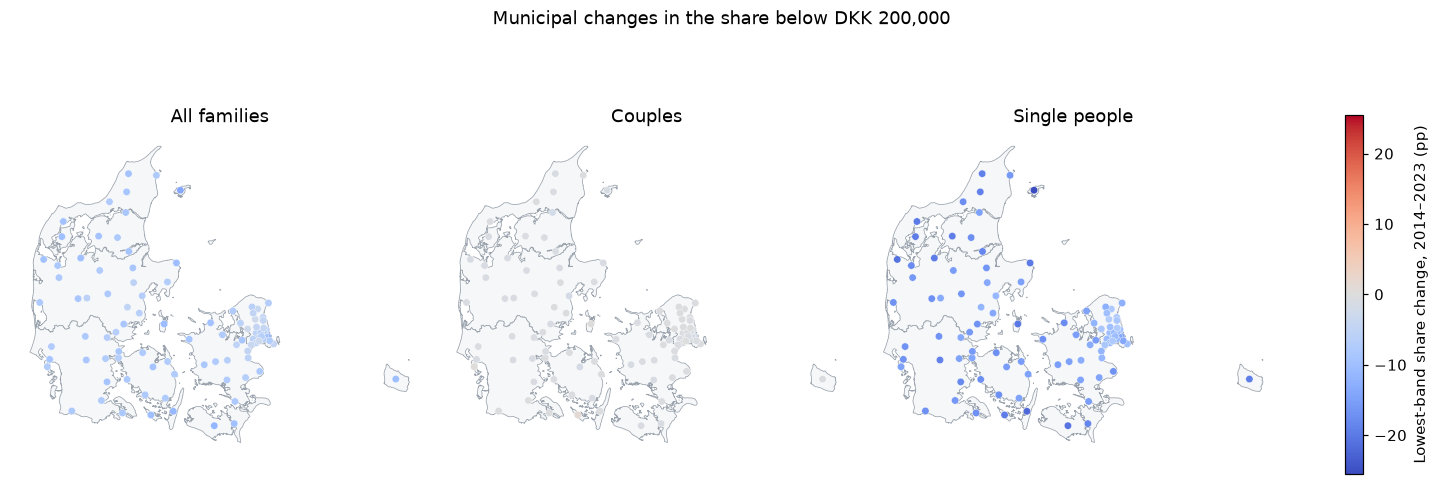

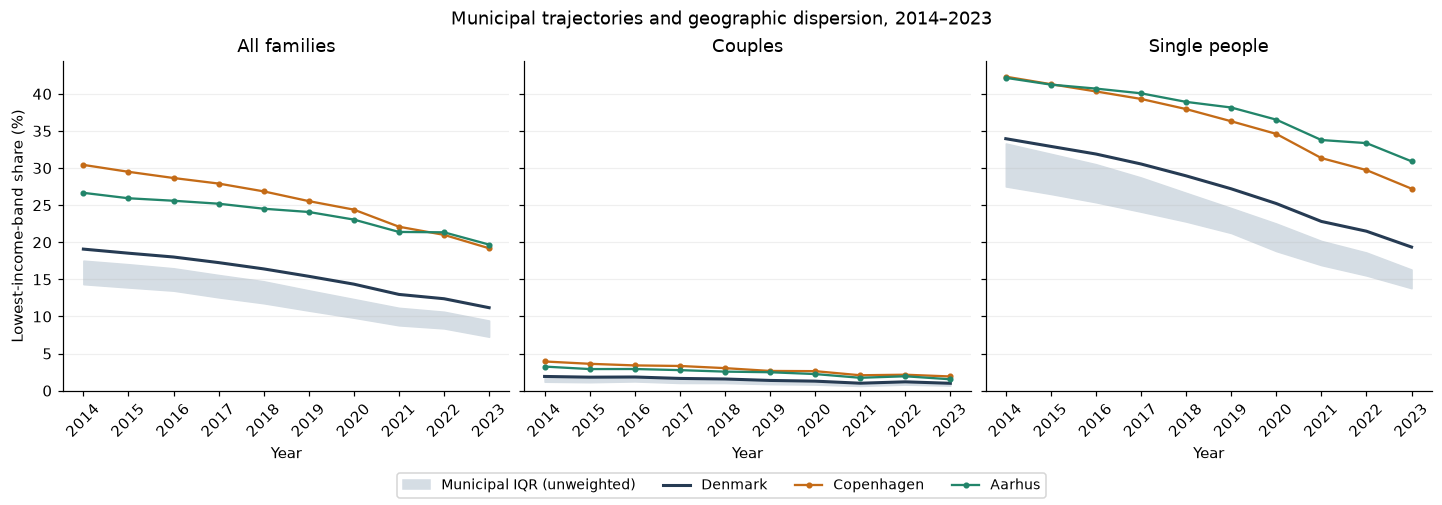

In [28]:
map_change_limit = municipal_change["change_pp"].abs().max()
change_norm = TwoSlopeNorm(vmin=-map_change_limit, vcenter=0, vmax=map_change_limit)
fig, axes = plt.subplots(1, 3, figsize=(13, 5), layout="constrained")
for ax, label in zip(axes, GROUPS.values()):
    change_values = municipal_change.loc[municipal_change["group"].eq(label), ["place", "change_pp"]]
    change_points = municipality_points.merge(change_values, on="place", validate="one_to_one")
    assert len(change_points) == 98
    map_regions.plot(ax=ax, facecolor="#F6F7F8", edgecolor="#9AA3AD", linewidth=0.5)
    change_points.plot(ax=ax, column="change_pp", cmap="coolwarm", norm=change_norm,
                       markersize=23, edgecolor="white", linewidth=0.25)
    ax.set_title(label)
    ax.set_axis_off()
fig.colorbar(ScalarMappable(norm=change_norm, cmap="coolwarm"), ax=list(axes),
             label="Lowest-band share change, 2014–2023 (pp)", shrink=0.7)
fig.suptitle("Municipal changes in the share below DKK 200,000")
plt.show()

national_lowest_shares = lowest_band_share("All Denmark")
municipal_dispersion = municipal_panel.groupby(["group", "year"])["share_pct"].quantile([0.25, 0.75]).unstack()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True, layout="constrained")
x_years = np.arange(len(YEARS))
for ax, label in zip(axes, GROUPS.values()):
    dispersion = municipal_dispersion.loc[label].reindex(YEARS)
    ax.fill_between(x_years, dispersion[0.25], dispersion[0.75], color="#D5DDE4", label="Municipal IQR (unweighted)")
    ax.plot(x_years, national_lowest_shares[label], color="#263B53", label="Denmark", linewidth=2)
    for place, color in [("Copenhagen", "#C46B17"), ("Aarhus", "#22856A")]:
        path = municipal_panel.loc[municipal_panel["group"].eq(label) & municipal_panel["place"].eq(place)].set_index("year")["share_pct"].reindex(YEARS)
        ax.plot(x_years, path, marker="o", markersize=3, color=color, label=place)
    ax.set_xticks(x_years, YEARS, rotation=45)
    ax.set(title=label, xlabel="Year")
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Lowest-income-band share (%)")
axes[0].set_ylim(bottom=0)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=4, fontsize=9)
fig.suptitle("Municipal trajectories and geographic dispersion, 2014–2023")
plt.show()

The lowest-band share falls in **all 98 municipalities** for all families and
single people, and in **95 of 98** for couples. Læsø has the largest decrease
for all families (**−13.84 pp**) and single people (**−25.52 pp**). For couples,
Copenhagen has the largest decrease (**−2.02 pp**), while Ærø records the largest
increase (**+1.41 pp**).

These findings extend the 2023 snapshot, but do not establish improvements in
real living standards. The DKK threshold is fixed, group membership can change,
and the CPI-adjusted mean analysis does not turn these band shares into
inflation-adjusted poverty measures. Large rank movements should be read
alongside the much more informative changes in percentage points and the
endpoint counts retained in `municipal_change`.

<a id="8-conclusions-and-limitations"></a>
## 8. Conclusions and limitations

The extended analysis changes the interpretation of the baseline results:

1. **The distribution shifts across fixed bands.** For all families, the
   lowest-band share falls from 19.08% to 11.18%, while the highest-band share
   rises from 7.58% to 15.61%. These are population shares, not individual transitions.
2. **Composition partly offsets the increase in the aggregate mean.** The
   symmetric decomposition assigns approximately +DKK 110,059 to changes within
   groups and −DKK 8,427 to the changing weights of couples and single people.
3. **Inflation absorbs much of the nominal increase.** Under the current-price
   interpretation and baseline band means, CPI-adjusted income increases by
   3.91%, 4.02%, and 9.07% for all families, couples, and single people. Each
   group's estimated real mean falls in 2022.
4. **Inequality trends depend on the open-band assumptions.** Although all three
   baseline Gini estimates decline, alternative tested band means reverse the
   direction for all families and single people. Couples show a decline in all
   12 scenarios, without establishing robustness outside that grid.
5. **Correlations depend on the specification.** Strong negative correlations
   in levels do not imply consistently negative associations between annual
   changes. Nominal and CPI-adjusted changes also give different results.
6. **Municipal trends add context to rankings.** Lowest-band shares fall in
   every municipality for all families and single people, and in 95 municipalities
   for couples. Aarhus has the highest aggregate share in 2023, while Copenhagen
   has the largest count; neither statistic is an official poverty measure.

### What the analysis can and cannot establish

| Issue | Implication |
| :--- | :--- |
| Grouped income data | Within-band variation is not observed; means and Gini coefficients are approximations. |
| Open-band scenarios | The grid demonstrates sensitivity but supplies neither confidence intervals nor exhaustive bounds. |
| Inflation adjustment | CPI-adjusted means assume current-year DKK and a common national price index; they retain midpoint errors. |
| Fixed band thresholds | Band shares and municipal rankings are not inflation-adjusted, even though a separate real-mean series is provided. |
| Different family sizes | Income is not equivalised or converted to disposable income, limiting living-standard comparisons. |
| Composition accounting | The decomposition is exact for the model but does not estimate causal effects or track individual families. |
| Short time series | Ten levels and nine changes are insufficient to support strong general or causal claims. |
| Municipal dispersion | The IQR weights municipalities equally and is a descriptive range, not an uncertainty interval. |
| Source verification | Observed counts match INDKF122, but the original download history and coordinate provenance remain unavailable. |
| Geographic markers | Municipal values are displayed at settlement coordinates on regional boundaries, not municipal polygons. |

Further work could use actual band income totals, finer income data, equivalised
disposable income, and demographic covariates. Those additions would address
measurement and comparability more directly than adding significance tests to
the current approximations.

<a id="9-data-provenance-and-references"></a>
## 9. Data provenance and references

All calculations run on the local snapshots. The new source extracts were
retrieved on **4 October 2026**; that date is not the original income-file
extraction date, which remains unknown.

- **Income counts:** `family_income_dk2014-2023.csv`. All 32,603 observed counts
  match [Statistics Denmark INDKF122](https://www.statistikbanken.dk/statbank5a/SelectVarVal/Define.asp?MainTable=INDKF122),
  whose official title identifies family income before tax. This exact match
  supports source identification; it does not recover the original processing
  notes. The archived comparison is `data_sources/INDKF122.verification.csv.gz`.
  The local income file and its 67 missing values are unchanged.
- **Consumer prices:** `denmark_cpi_2014-2023.csv`, the unmodified API response
  for the annual-average CPI from [Statistics Denmark PRIS8](https://www.statbank.dk/PRIS8),
  selecting 2014–2023 and `TYPE=INDEKS`. The published reference is 1900=100;
  the notebook rebases the series to 2014=100 for display and deflation.
  [CPI methodology](https://www.dst.dk/en/Statistik/dokumentation/documentationofstatistics/consumer-price-index/statistical-presentation)
  explains its consumer-price coverage; the saved metadata include the 2020
  uncertainty note.
- **Income definitions:** [Statistics Denmark — Income Statistics](https://www.dst.dk/en/Statistik/dokumentation/documentationofstatistics/income-statistics/statistical-presentation)
  distinguishes income before tax, disposable income, and equivalised income.
  This notebook's grouped family-income Gini is not the agency's official
  measure of inequality in equivalised disposable income.
- **Regional backdrop:** `gadm41_DNK_1.json`. Its filename and embedded feature
  metadata identify a GADM 4.1 regional layer for Denmark. The original download
  record is not included.
- **Settlement coordinates:** `dk.json`. The local file supplies names,
  longitude, and latitude; its original provider and download date are not
  recorded. Population fields are not used.

`data_sources/sources.json` records source URLs, requests, retrieval date, and
checksums. The requests and table metadata are saved alongside the snapshots;
`data_sources/README.md` explains how to retrieve a fresh copy without changing
the analysis's archived inputs. No API calls are made when running the notebook.